  ✓ Confirmed all per-window global_fill keys present: ['global_fill_10d', 'global_fill_5d', 'global_fill_1d']

Loaded: 149 months, 1699 features, 1353 surviving
Full theme groups built: 13 themes, 1353 factors, every factor covered exactly once
H^2 IDENTITY VERIFICATION (every theme, all evaluation windows)
  window=10d: max|H_agg^2 - sum(H_theme^2)| over 137 valid months = 2.13e-14  ->  PASS
  window=5d: max|H_agg^2 - sum(H_theme^2)| over 137 valid months = 1.07e-14  ->  PASS
  window=1d: max|H_agg^2 - sum(H_theme^2)| over 137 valid months = 7.11e-15  ->  PASS

Overall: ALL WINDOWS PASS
Window stability (smaller stability_score = more consistent monthly vs quarterly significance):
  2 weeks   : monthly_p=0.3150  quarterly_p=0.5560  stability_score=0.2411
  1 week    : monthly_p=0.4897  quarterly_p=0.4547  stability_score=0.0350
  1 day     : monthly_p=0.5423  quarterly_p=0.5858  stability_score=0.0435

Selected window for Fig 1 / KDE: 5d (1 week) -- most consistent significance acros

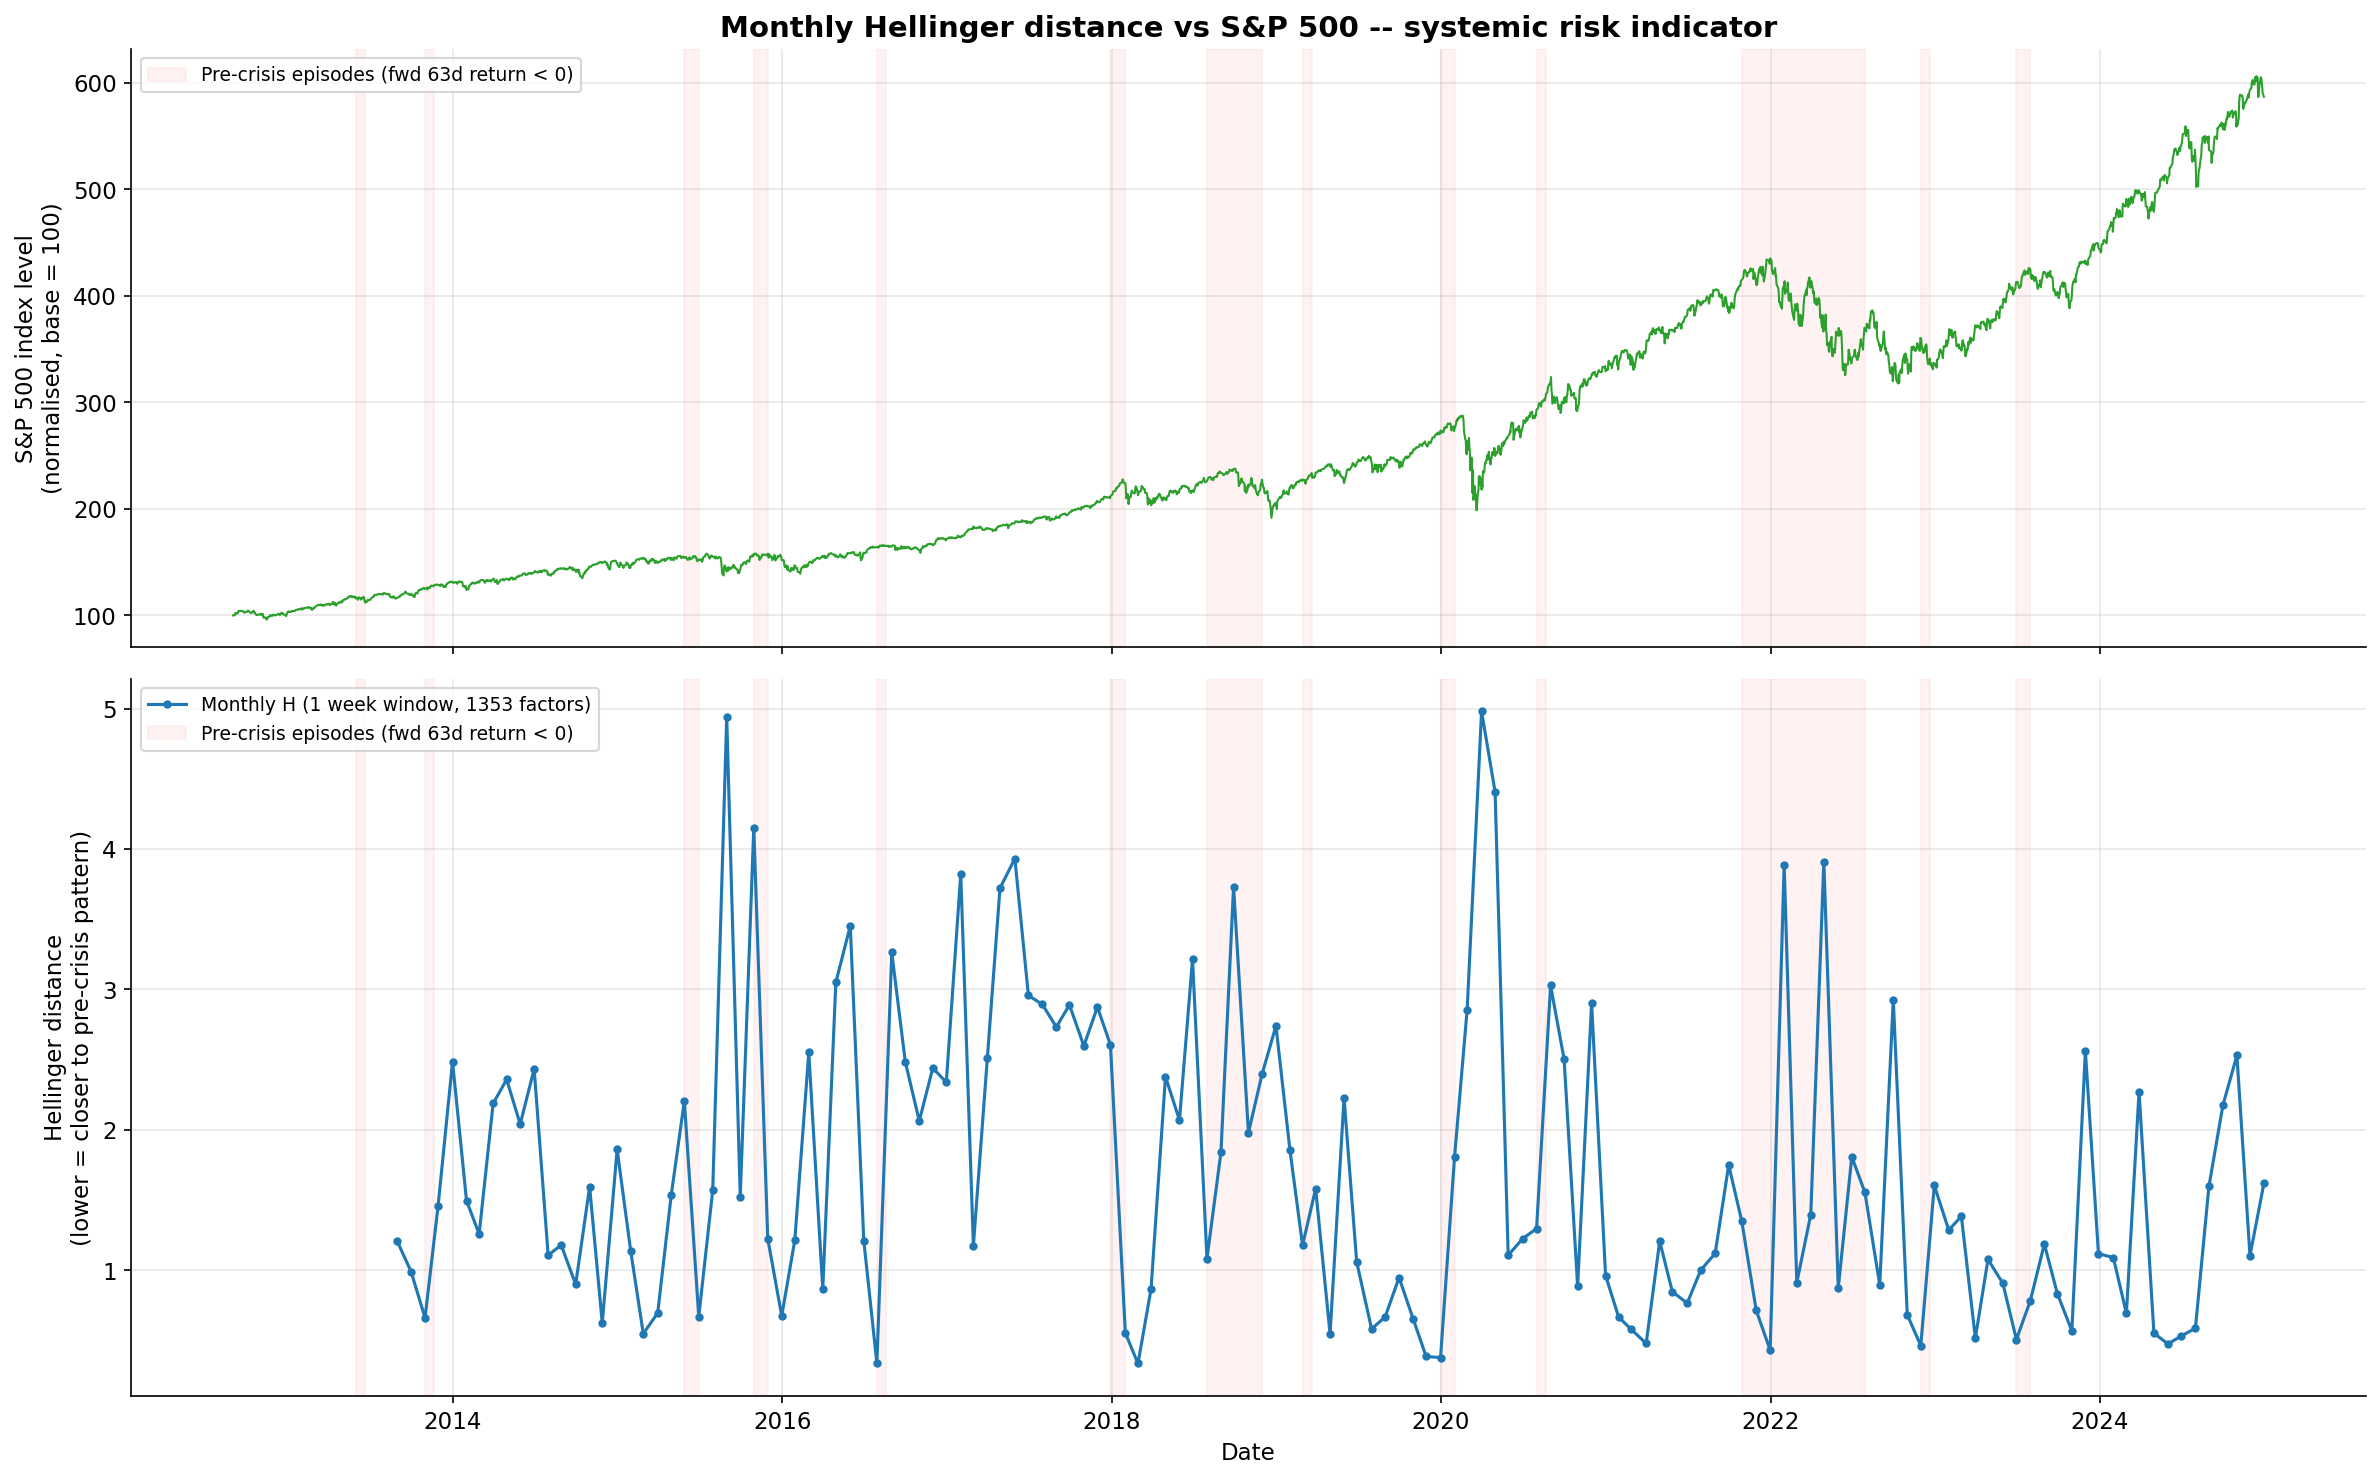

Saved: fig01_monthly_hellinger_agg_full_moments.png
AGGREGATE KDE POLARISATION


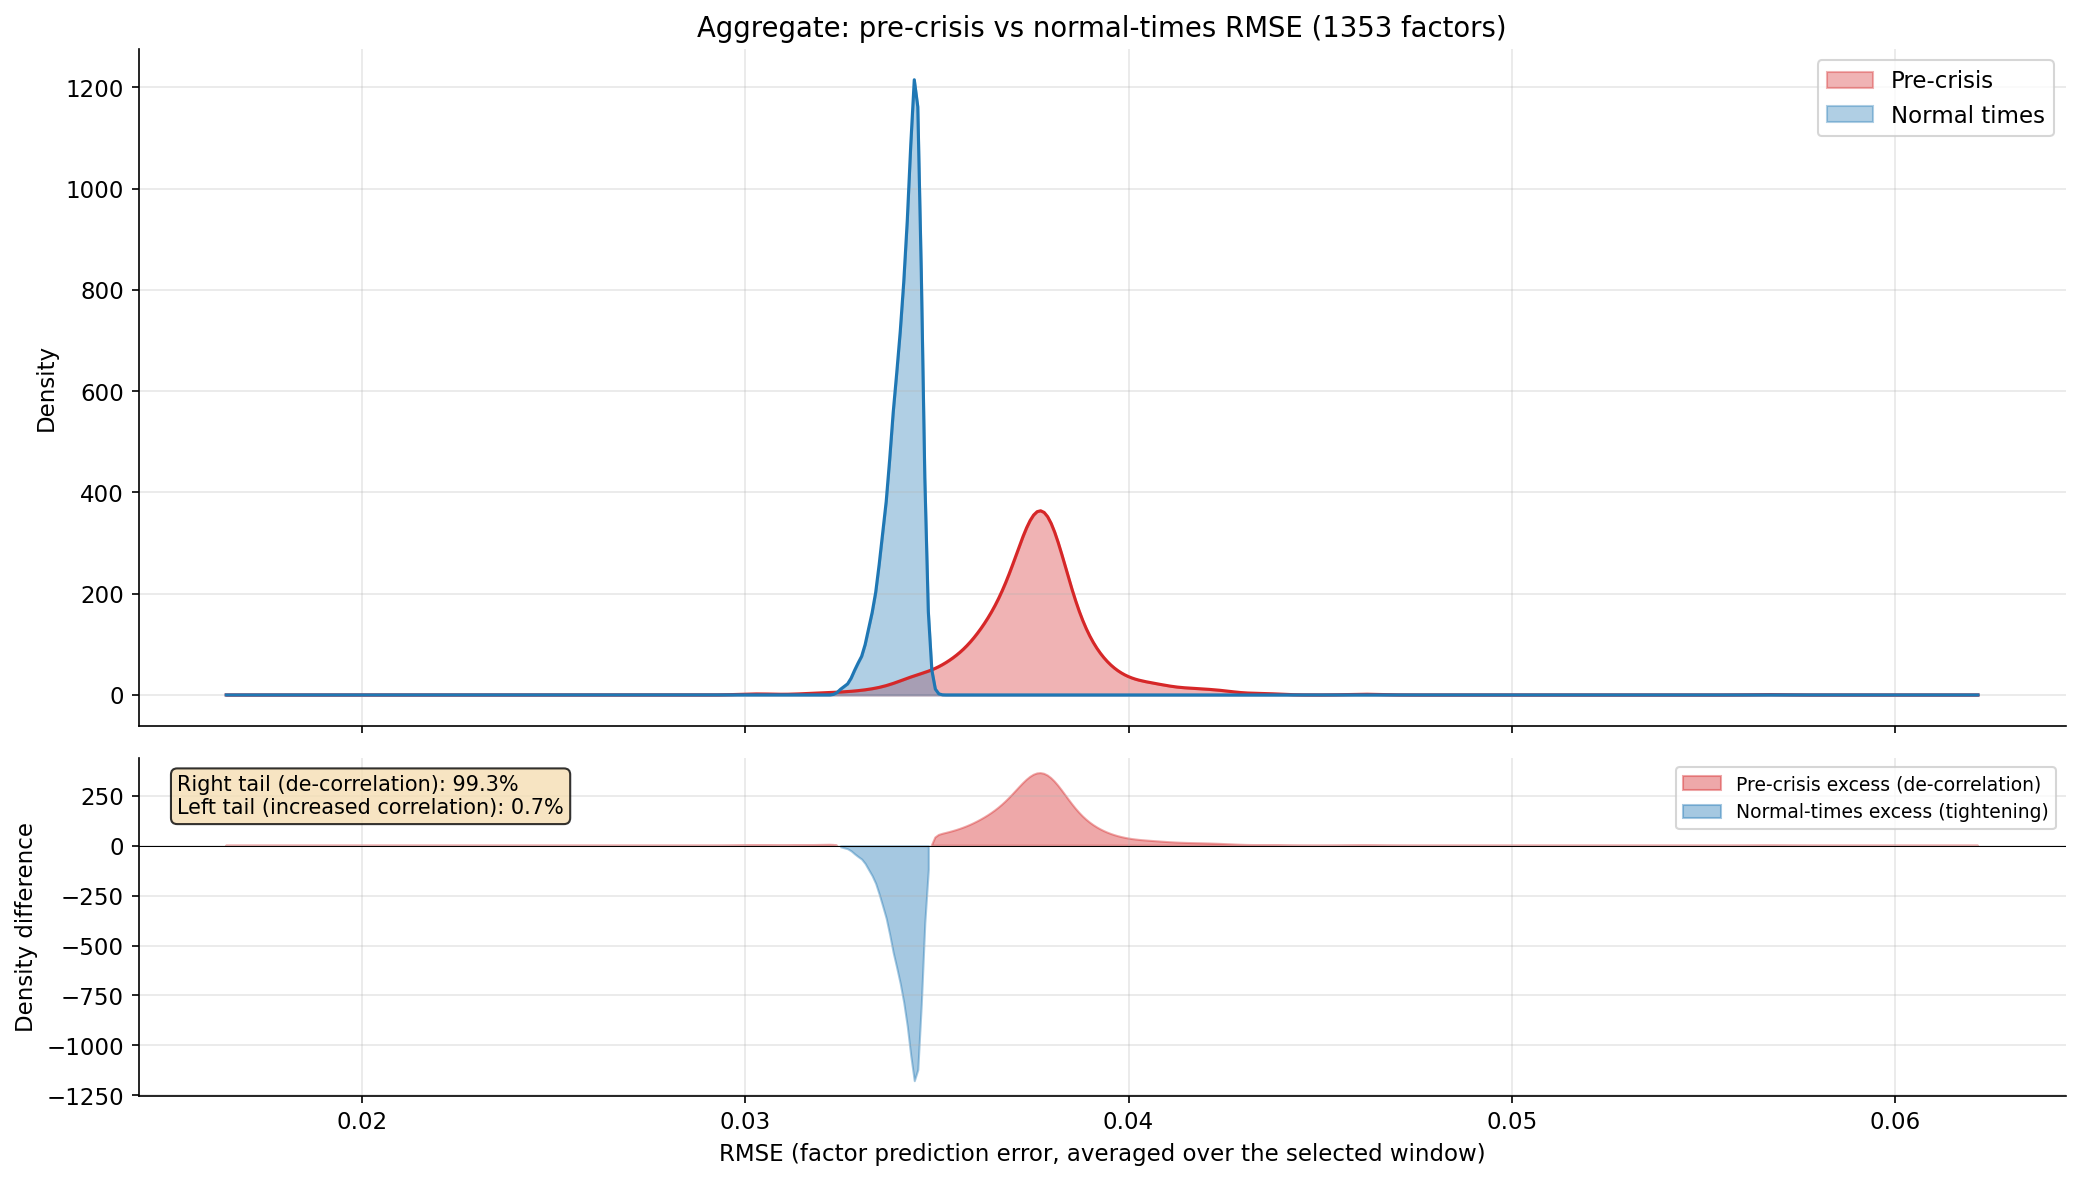

  Aggregate: pre-crisis vs normal-times RMSE (1353 factors): right=99.3%, left=0.7%
Themes shown individually (>= 2% of H^2 in some month): 13
Themes merged into 'Other': 0


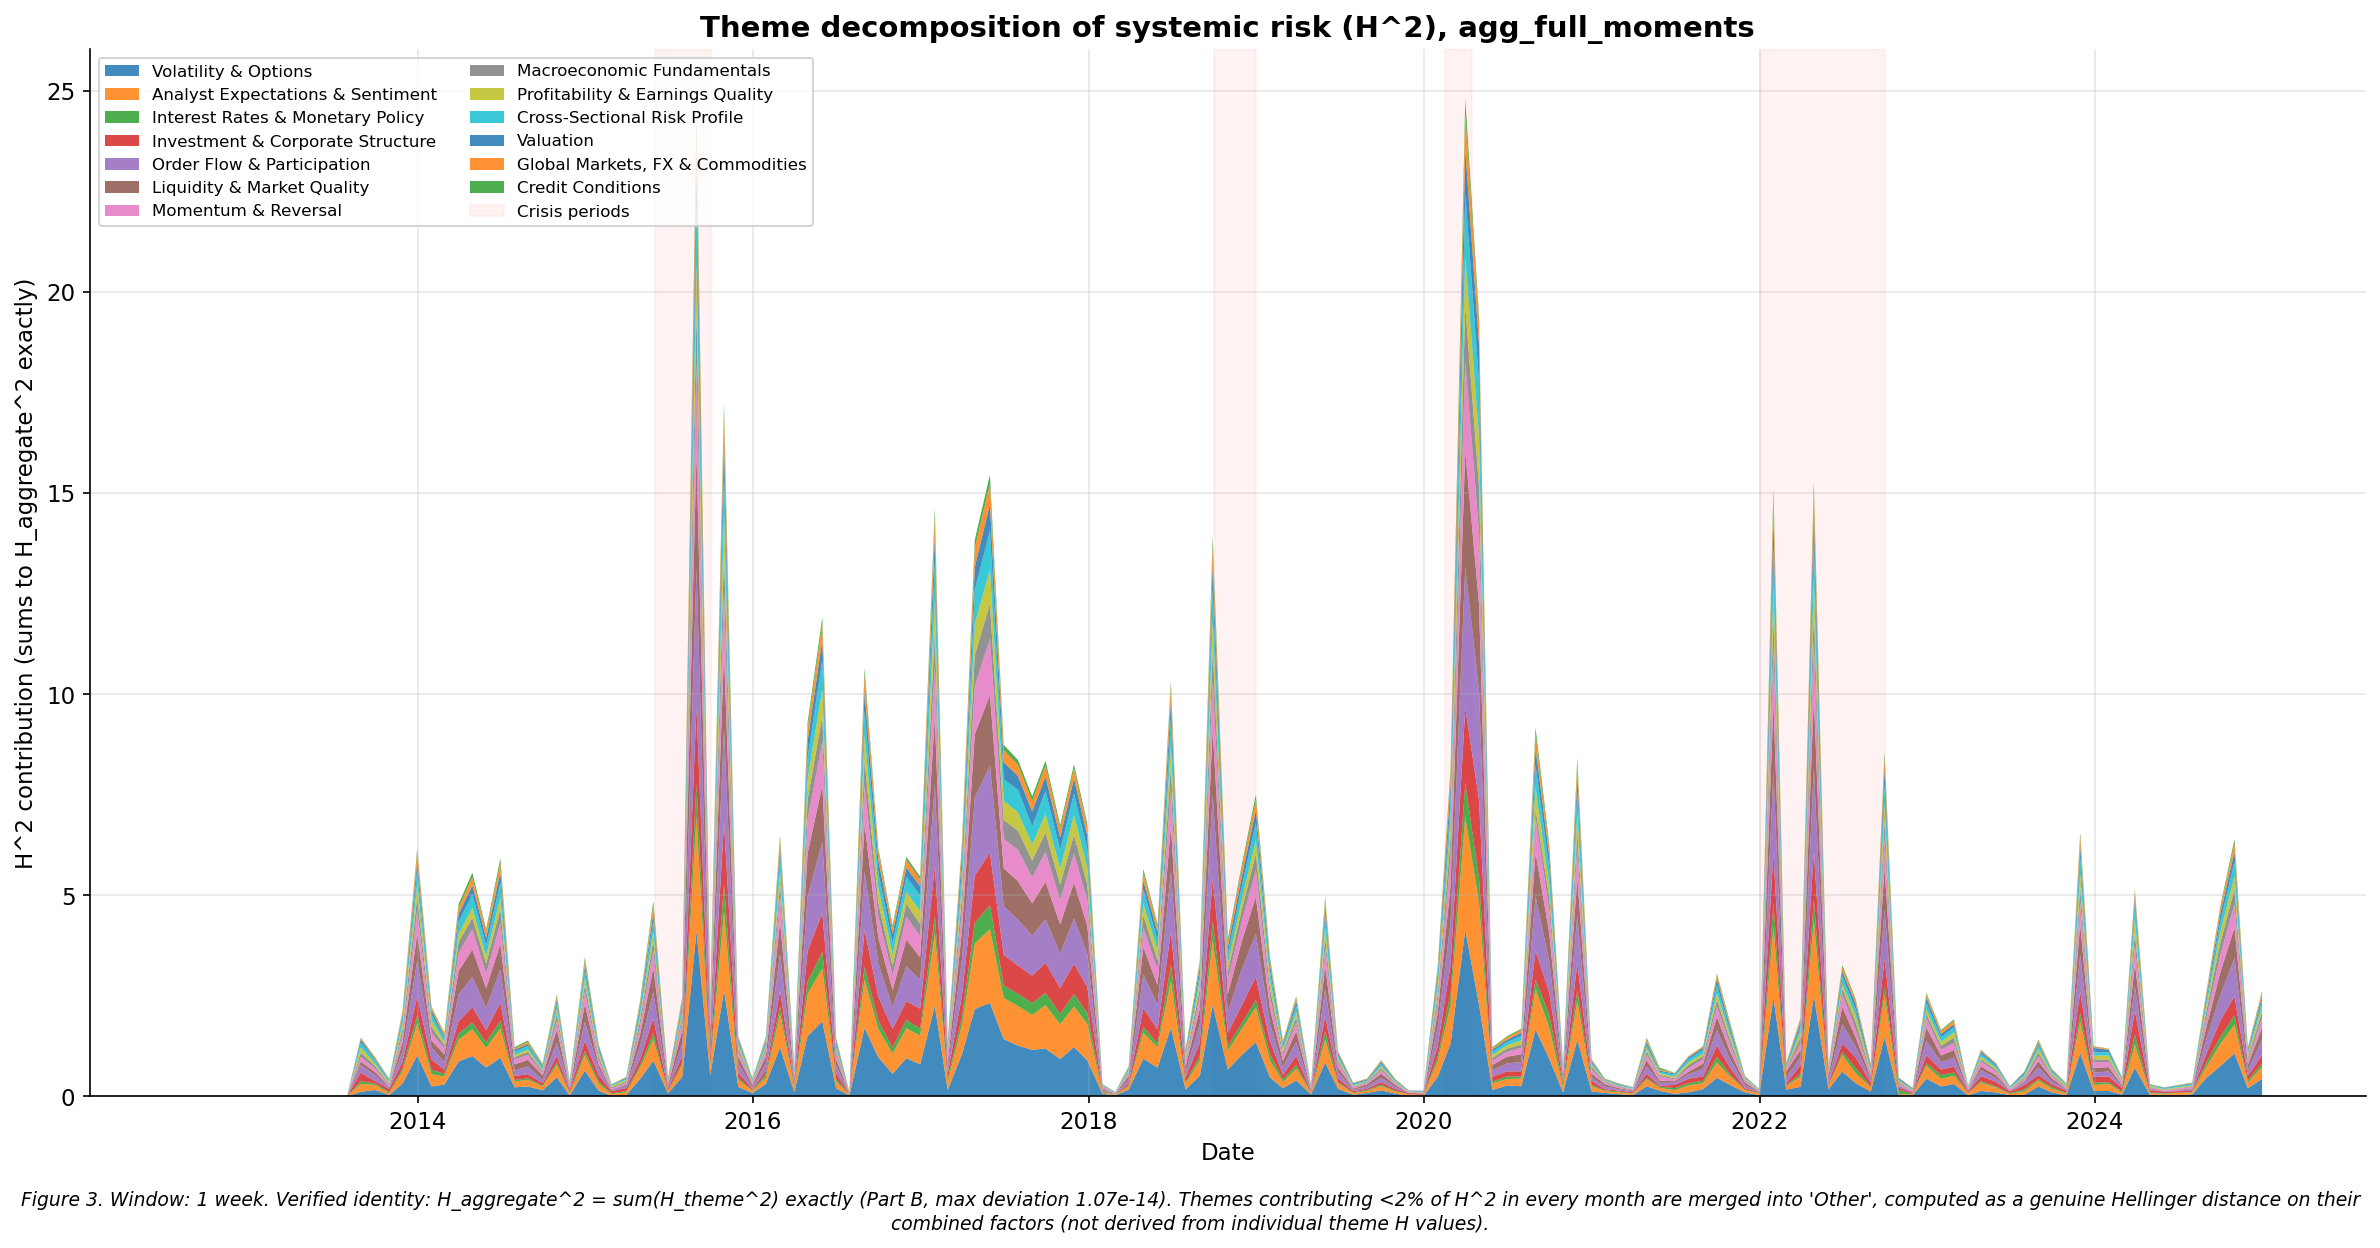

Saved: fig03_theme_decomposition_agg_full_moments.png
TAIL FRACTIONS BY THEME (window=1 week)
                           theme  n_factors  left_tail_pct  right_tail_pct
                       Valuation         59   2.205777e-02        0.977942
Analyst Expectations & Sentiment        159   2.095227e-02        0.979048
      Liquidity & Market Quality        152   1.920591e-02        0.980794
      Macroeconomic Fundamentals         74   1.598996e-02        0.984010
            Volatility & Options        220   1.369287e-02        0.986307
Investment & Corporate Structure        111   1.126819e-02        0.988732
      Order Flow & Participation        184   1.751564e-03        0.998248
    Cross-Sectional Risk Profile         86   1.354000e-03        0.998646
               Credit Conditions         21   5.813284e-04        0.999419
             Momentum & Reversal        122   3.761565e-04        0.999624
Profitability & Earnings Quality         71   2.047316e-04        0.999795
Global

In [3]:
# %% [markdown]
# # Polymodel Results and Figures (Stage 5 Pipeline)
#
# ═══════════════════════════════════════════════════════════════════════
# STRUCTURE
# ═══════════════════════════════════════════════════════════════════════
# Part A: Setup -- load Notebook 2's saved outputs (with a guard confirming
#         the per-window global_fill fix actually landed before proceeding)
# Part B: THE H^2 IDENTITY -- derivation + numerical verification
#         (must run before Part F, since Part F's figure depends on it
#         being true; Part F reuses Part B's per-theme H arrays rather
#         than recomputing them)
# Part C: Window selection for Fig 1 / KDE (data-driven, not arbitrary)
# Part D: TABLE 1 -- evaluation window sensitivity (the actual deliverable
#         table: monthly t/p, quarterly t/p, H range, significance stars --
#         printed AND saved, not left implicit inside Part C's selection logic)
# Part E: Fig 1 -- Hellinger distance vs S&P 500
# Part F: Aggregate KDE polarisation
# Part G: Theme H^2 decomposition (stacked area) -- reuses Part B's results
# Part H: Tail-fraction table (themes, ranked)
# Part I: Inter-theme correlation (carries the "do themes add information
#         beyond the aggregate" argument on its own)
#
# ═══════════════════════════════════════════════════════════════════════
# WHAT IS DELIBERATELY NOT HERE, AND WHY
# ═══════════════════════════════════════════════════════════════════════
# - The likelihood-ratio test comparing univariate vs multivariate theme
#   regression: INVALID. H_agg is a nonlinear (Euclidean-norm) function
#   of the theme-level H_k values, so a linear-in-H_agg logit does not
#   nest a linear-in-{H_k} logit -- the LR statistic has no chi-squared
#   reference distribution here.
# - The multivariate regression's AIC/BIC/pseudo-R^2, even reported
#   "for reference": with ~45 quarterly observations against 13+ theme
#   predictors, this fit is exactly the p~n regime the regularisation
#   attempt (also cut) was trying to compensate for. Its diagnostics
#   inherit that instability. Cut entirely.
# - Per-theme and per-subtheme significance tables across every moment
#   type: comfortably 400+ unpenalised tests. Cut. The tail-fraction
#   table (Part H) gives an honest, compact summary instead.
# - 13 individual per-theme KDE plots: replaced by Part H's ranked table.
# - Full noise-filter-sensitivity table (12 rows) and full autocorrelation
#   diagnostic table: already computed and printed in Notebook 2 --
#   referenced in one sentence, not reproduced.
#
# The argument "do themes carry more information than the single
# aggregate H" is carried ENTIRELY by Part I now that the regression
# section is gone -- a correlation-based argument the reader can verify
# at a glance, rather than AIC values from an admittedly unstable
# regression.

DATASET_NAME = "agg_full_moments"   # or "agg_means"

# ==========================================================================
# %% [markdown]
# ## Part A: Setup

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from scipy.stats import gaussian_kde
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# NumPy 2.0 renamed np.trapz to np.trapezoid -- use whichever is present
# so this notebook doesn't crash deep inside a KDE plot on older NumPy.
_trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

ROOT = Path("../..")
RESULTS_ROOT = ROOT / "Data" / "Results" / "Reproducing_Hellinger_Polymodel"
DATA_PM  = RESULTS_ROOT / "intermediate"
FIG_DIR  = RESULTS_ROOT / "figures"
TABLES_DIR = RESULTS_ROOT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (14, 6), "figure.dpi": 150, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

BLUE = "#1f77b4"; GREEN = "#2ca02c"; RED = "#d62728"; GRAY = "#7f7f7f"

CRISES = {
    "2015 China":  ("2015-06-01", "2015-10-01"),
    "2018 Q4":     ("2018-10-01", "2019-01-01"),
    "COVID":       ("2020-02-15", "2020-04-15"),
    "2022 Bear":   ("2022-01-01", "2022-10-01"),
}

def shade_crises(ax):
    first = True
    for name, (s, e) in CRISES.items():
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                   color="#ffe0e0", alpha=0.4, zorder=0,
                   label="Crisis periods" if first else None)
        first = False


def logistic_t_local(signal, fwd_return):
    valid = ~np.isnan(signal) & ~np.isnan(fwd_return)
    if valid.sum() < 30:
        return None
    y = (fwd_return[valid] > 0).astype(float)
    X = sm.add_constant(signal[valid])
    try:
        fit = sm.Logit(y, X).fit(disp=0)
        return {"n": int(valid.sum()), "t": fit.tvalues[1], "p": fit.pvalues[1]}
    except Exception:
        return None


# %%
# ── Load Notebook 2's outputs (dataset-suffixed) ──

hell_path  = DATA_PM / f"hellinger_monthly_{DATASET_NAME}.npz"
rmse_path  = DATA_PM / f"rmse_matrices_{DATASET_NAME}.npz"
target_path = DATA_PM / f"polymodel_target_{DATASET_NAME}.parquet"
feat_path  = DATA_PM / f"polymodel_features_unlagged_{DATASET_NAME}.parquet"
meta_path  = DATA_PM / f"polymodel_feature_meta_{DATASET_NAME}.csv"
params_path = DATA_PM / f"lnlm_params_{DATASET_NAME}.npz"

for p in [hell_path, rmse_path, target_path, feat_path, meta_path, params_path]:
    assert p.exists(), f"Not found: {p} -- run Notebooks 1 and 2 for DATASET_NAME='{DATASET_NAME}' first."

params = np.load(params_path, allow_pickle=True)
param_dates = params["dates"]
feature_names = list(params["feature_names"])
n_months = len(param_dates)
param_dates_ts = pd.DatetimeIndex(param_dates)

hell = np.load(hell_path, allow_pickle=True)
monthly_fwd_63d = hell["monthly_fwd_63d"]
combined_surviving = hell["combined_surviving_idx"]

rmse_data = np.load(rmse_path, allow_pickle=True)

target_df = pd.read_parquet(target_path)
features_df = pd.read_parquet(feat_path)
all_dates = pd.to_datetime(features_df["date"]).values
daily_returns = target_df["daily_return"].values

meta = pd.read_csv(meta_path, dtype={"subtheme_id": str, "theme_id": str})

eval_start = int(np.searchsorted(all_dates, param_dates[0]))

EVAL_WINDOWS = [10, 5, 1]
WINDOW_NAMES = {10: "2 weeks", 5: "1 week", 1: "1 day"}

# ── MANDATORY GUARD: confirm Notebook 2's per-window global_fill fix
# actually landed before proceeding. If this raises, you're running an
# earlier (uncorrected) version of Notebook 2's output -- go back and
# re-run the CORRECTED version (per-window global_fill_10d/5d/1d), not
# an older draft that saved a single unsuffixed "global_fill" key. ──
required_fill_keys = [f"global_fill_{w}d" for w in EVAL_WINDOWS]
missing_keys = [k for k in required_fill_keys if k not in hell.files]
assert not missing_keys, (
    f"Missing key(s) {missing_keys} in {hell_path}. This notebook requires "
    f"a SEPARATE global_fill array per evaluation window (the fix for the "
    f"cross-window imputation bug). Re-run the corrected Notebook 2 -- do "
    f"not proceed against an older, uncorrected output. STOP."
)
print(f"  ✓ Confirmed all per-window global_fill keys present: {required_fill_keys}")

print(f"\nLoaded: {n_months} months, {len(feature_names)} features, "
      f"{len(combined_surviving)} surviving")


# ==========================================================================
# %% [markdown]
# ## Part B: The H^2 Decomposition Identity
#
# ### The claim
# For any partition of the surviving factors into disjoint groups (e.g.
# themes), the SQUARE of the aggregate Hellinger distance equals the sum
# of the squares of each group's own Hellinger distance:
#
#     H_aggregate^2  =  sum over themes k of  H_theme_k^2
#
# ### Why this is true (and what it depends on)
# Section 4.5.1 shows Hellinger distance here reduces algebraically to
# the Euclidean L2 distance between square-root-transformed vectors:
#
#     H = (1/sqrt(2)) * || sqrt(row) - sqrt(R_pre) ||_2
#
# Squared Euclidean distance between two vectors is a SUM OF PER-
# COORDINATE SQUARED TERMS. Any sum of terms indexed by a set splits
# additively across any partition of that index set -- this is a direct,
# mechanical consequence of the metric being additive over coordinates,
# independent of what the coordinates represent or how the reference
# vector R_pre was built.
#
# ### The one real precondition
# Each theme's H_theme_k must be computed as its OWN independent
# Hellinger distance -- with its OWN pc_num/pc_den accumulation running
# only over that theme's factors -- NOT by slicing a pre-computed
# aggregate reference vector down to a theme's coordinates.
#
# ### The only way the identity can fail
# NOT theme size. A theme with exactly 1 factor still contributes
# exactly one coordinate's squared term -- correctly. The identity can
# ONLY fail if a surviving factor is EXCLUDED from every theme group
# used in the check. Accordingly, the verification below uses EVERY
# theme with >=1 surviving factor -- no size filter at this stage.
#
# The per-theme H arrays computed here (at all three windows) are kept
# and reused directly by Part G's figure -- not recomputed there.

# %%
ALPHA_MONTHLY = np.exp(-np.log(2) / 120)
FWD_LAG = 3
alpha_lag = ALPHA_MONTHLY ** FWD_LAG


def compute_hellinger(rmse_matrix, surviving_idx, fwd_returns, fill_matrix,
                      subset_positions=None):
    """
    Identical logic to Notebook 2's compute_hellinger. fill_matrix MUST be
    the fill array computed for THIS SAME evaluation window (Notebook 2's
    global_fill_{w}d) -- using a different window's fill array here would
    reintroduce the cross-window imputation bug fixed in Notebook 2.
    """
    n_surv = len(surviving_idx)
    rmse_sub = rmse_matrix[:, surviving_idx]

    fill_sub = fill_matrix if subset_positions is None else fill_matrix[:, subset_positions]

    pc_num = np.zeros(n_surv); pc_den = 0.0
    nt_num = np.zeros(n_surv); nt_den = 0.0
    H = np.full(len(fwd_returns), np.nan)

    for m in range(len(fwd_returns)):
        pc_num *= ALPHA_MONTHLY; pc_den *= ALPHA_MONTHLY
        nt_num *= ALPHA_MONTHLY; nt_den *= ALPHA_MONTHLY

        row = rmse_sub[m].copy()
        nan_mask = np.isnan(row)
        if nan_mask.any():
            row[nan_mask] = fill_sub[m][nan_mask]

        nt_num += row; nt_den += 1.0

        m_new = m - FWD_LAG
        if m_new >= 0 and not np.isnan(fwd_returns[m_new]) and fwd_returns[m_new] < 0:
            weight = fwd_returns[m_new] ** 2 * alpha_lag
            pc_row = rmse_sub[m_new].copy()
            pc_nan = np.isnan(pc_row)
            if pc_nan.any():
                pc_row[pc_nan] = fill_sub[m_new][pc_nan]
            pc_num += weight * pc_row; pc_den += weight

        if pc_den > 1e-20:
            R_pre = pc_num / pc_den
            diff = np.sqrt(row) - np.sqrt(R_pre)
            H[m] = (1.0 / np.sqrt(2)) * np.sqrt(np.sum(diff ** 2))

    pc_ref = pc_num / pc_den if pc_den > 1e-20 else None
    nt_ref = nt_num / nt_den if nt_den > 1e-20 else None
    return {"H": H, "pc_ref": pc_ref, "nt_ref": nt_ref}


# %%
# ── B.1: Build FULL theme groupings -- every theme, any size, and assert
# every surviving factor is covered exactly once. ──

def build_full_theme_groups(combined_surviving, feature_names, meta):
    full_theme_groups = {}
    theme_display_names = {}

    for pos, idx in enumerate(combined_surviving):
        fname = feature_names[idx]
        match = meta[meta["column"] == fname]
        if len(match) == 0:
            continue
        tid = match.iloc[0]["theme_id"]
        tname = match.iloc[0]["theme_name"]
        full_theme_groups.setdefault(tid, []).append(pos)
        theme_display_names[tid] = tname

    covered = sorted(p for positions in full_theme_groups.values() for p in positions)
    expected = list(range(len(combined_surviving)))
    missing = set(expected) - set(covered)
    assert not missing, (
        f"{len(missing)} surviving factor(s) not assigned to any theme "
        f"(positions: {sorted(missing)[:10]}...) -- the H^2 identity WILL "
        f"fail until every factor is accounted for. Check the taxonomy "
        f"for unassigned columns."
    )
    return full_theme_groups, theme_display_names


full_theme_groups, theme_display_names = build_full_theme_groups(
    combined_surviving, feature_names, meta
)
print(f"Full theme groups built: {len(full_theme_groups)} themes, "
      f"{len(combined_surviving)} factors, every factor covered exactly once")

# %%
# ── B.2: Run the verification at each evaluation window, KEEPING each
# theme's per-window H series for reuse in Part G (no recomputation there). ──

def verify_h_squared_identity(window, rmse_data, monthly_fwd_63d, hell,
                              combined_surviving, full_theme_groups):
    rmse_w = rmse_data[f"rmse_{window}d"]
    fill_w = hell[f"global_fill_{window}d"]
    H_agg = hell[f"H_{window}d"]

    theme_H_series_w = {}
    theme_H_sq_sum = np.zeros_like(H_agg)

    for tid, positions in full_theme_groups.items():
        theme_idx = combined_surviving[positions]
        r = compute_hellinger(rmse_w, theme_idx, monthly_fwd_63d, fill_w,
                              subset_positions=positions)
        H_theme = np.nan_to_num(r["H"], nan=0.0)
        theme_H_series_w[tid] = {"H": H_theme, "pc_ref": r["pc_ref"], "nt_ref": r["nt_ref"]}
        theme_H_sq_sum += H_theme ** 2

    valid = ~np.isnan(H_agg)
    diffs = np.abs(H_agg[valid] ** 2 - theme_H_sq_sum[valid])
    max_diff = diffs.max() if len(diffs) > 0 else np.nan
    is_close = np.allclose(H_agg[valid] ** 2, theme_H_sq_sum[valid], atol=1e-8)

    print(f"  window={window}d: max|H_agg^2 - sum(H_theme^2)| over "
          f"{valid.sum()} valid months = {max_diff:.2e}  ->  "
          f"{'PASS' if is_close else 'FAIL'}")

    return is_close, max_diff, theme_H_sq_sum, theme_H_series_w


print("=" * 80)
print("H^2 IDENTITY VERIFICATION (every theme, all evaluation windows)")
print("=" * 80)

identity_results = {}
for w in EVAL_WINDOWS:
    is_close, max_diff, theme_H_sq_sum, theme_H_series_w = verify_h_squared_identity(
        w, rmse_data, monthly_fwd_63d, hell, combined_surviving, full_theme_groups
    )
    identity_results[w] = {
        "is_close": is_close, "max_diff": max_diff,
        "theme_H_sq_sum": theme_H_sq_sum, "theme_H_series": theme_H_series_w,
    }
    if not is_close:
        print(f"    IDENTITY FAILED at window={w} -- this should not happen "
              f"given B.1's coverage assertion. Investigate before trusting "
              f"Part G's figure.")

all_pass = all(r["is_close"] for r in identity_results.values())
print(f"\nOverall: {'ALL WINDOWS PASS' if all_pass else 'AT LEAST ONE WINDOW FAILED'}")
assert all_pass, "H^2 identity failed for at least one window -- stop and investigate before proceeding to Part G."


# ==========================================================================
# %% [markdown]
# ## Part C: Window Selection for Fig 1 / KDE
#
# Section 4.6.2 frames all three evaluation windows (1-day, 1-week,
# 2-week) as a sensitivity test, not as a ranked search for a single
# "best" window -- mirroring Barrau & Douady's own horizon-sensitivity
# check across 1-12 months. Accordingly, no window is designated
# "primary" by default. Instead: the window used for Fig 1 and the
# aggregate KDE is the one Table 1 (Part D, immediately following) shows
# to be the MOST STABLE across monthly and quarterly sampling -- and
# this selection rule is stated explicitly in each figure's caption.

# %%
window_stability = {}
window_stats_cache = {}   # cached so Part D's Table 1 reuses these, no recompute

for w in EVAL_WINDOWS:
    H = hell[f"H_{w}d"]
    lg_m = logistic_t_local(H, monthly_fwd_63d)

    q_ts = []; q_ps = []
    for offset in range(3):
        q_idx = np.arange(offset, n_months, 3)
        lg_q = logistic_t_local(H[q_idx], monthly_fwd_63d[q_idx])
        if lg_q:
            q_ts.append(lg_q["t"]); q_ps.append(lg_q["p"])

    window_stats_cache[w] = {"lg_m": lg_m, "q_ts": q_ts, "q_ps": q_ps}

    if lg_m and len(q_ps) == 3:
        avg_qp = np.mean(q_ps)
        stability_score = abs(lg_m["p"] - avg_qp)
        window_stability[w] = {"monthly_p": lg_m["p"], "quarterly_p": avg_qp,
                               "stability_score": stability_score}

print("Window stability (smaller stability_score = more consistent "
      "monthly vs quarterly significance):")
for w, v in window_stability.items():
    print(f"  {WINDOW_NAMES[w]:10s}: monthly_p={v['monthly_p']:.4f}  "
          f"quarterly_p={v['quarterly_p']:.4f}  "
          f"stability_score={v['stability_score']:.4f}")

SELECTED_WINDOW = min(window_stability, key=lambda w: window_stability[w]["stability_score"])
print(f"\nSelected window for Fig 1 / KDE: {SELECTED_WINDOW}d "
      f"({WINDOW_NAMES[SELECTED_WINDOW]}) -- most consistent significance "
      f"across monthly and quarterly sampling (see Table 1, Part D).")


# %%
# ── C-SRI: Douady's exact regressor, SRI_t = 1{H_t < H_(t-1)} ──
# Predicts D_t = 1{r_{t->t+63} > 0} directly on the binary momentum flag
# rather than the level of H_t. This discards the magnitude of the change
# and loses one further observation (SRI is undefined at the first valid
# H), but is the literal specification in Barrau & Douady's Eq. 4.4.
# Reported as a robustness check alongside the level regression, not a
# replacement for it — see Section 3.6.1.

window_stats_cache_sri = {}

for w in EVAL_WINDOWS:
    SRI = hell[f"SRI_{w}d"]
    lg_m = logistic_t_local(SRI, monthly_fwd_63d)

    q_ts = []; q_ps = []
    for offset in range(3):
        q_idx = np.arange(offset, n_months, 3)
        lg_q = logistic_t_local(SRI[q_idx], monthly_fwd_63d[q_idx])
        if lg_q:
            q_ts.append(lg_q["t"]); q_ps.append(lg_q["p"])

    window_stats_cache_sri[w] = {"lg_m": lg_m, "q_ts": q_ts, "q_ps": q_ps}

# %%
table1_sri_rows = []
for w in EVAL_WINDOWS:
    cached = window_stats_cache_sri[w]
    lg_m, q_ts, q_ps = cached["lg_m"], cached["q_ts"], cached["q_ps"]

    m_t = lg_m["t"] if lg_m else np.nan
    m_p = lg_m["p"] if lg_m else np.nan
    q_t = np.mean(q_ts) if len(q_ts) == 3 else np.nan
    q_p = np.mean(q_ps) if len(q_ps) == 3 else np.nan

    star = ""
    if not np.isnan(q_p):
        star = "***" if q_p < 0.01 else "**" if q_p < 0.05 else "*" if q_p < 0.10 else ""

    table1_sri_rows.append({
        "window": WINDOW_NAMES[w], "window_days": w,
        "monthly_t": m_t, "monthly_p": m_p,
        "quarterly_t": q_t, "quarterly_p": q_p,
        "significance": star,
    })

table1_sri_df = pd.DataFrame(table1_sri_rows)

print("=" * 95)
print(f"TABLE 1b: BINARY SRI SPECIFICATION (Douady's exact regressor, {DATASET_NAME})")
print("  SRI_t = 1{H_t < H_(t-1)}; predicted sign is NEGATIVE (opposite of the")
print("  level regression's positive prediction — see Section 3.6.1)")
print("=" * 95)
print(f"\n  {'Window':12s} {'Monthly t':>10s} {'Monthly p':>10s} "
      f"{'Quarterly t':>12s} {'Quarterly p':>12s}")
print(f"  {'-' * 60}")
for _, r in table1_sri_df.iterrows():
    print(f"  {r['window']:12s} {r['monthly_t']:+10.3f} {r['monthly_p']:10.4f} "
          f"{r['quarterly_t']:+12.3f} {r['quarterly_p']:12.4f} {r['significance']}")

table1_sri_df.to_csv(TABLES_DIR / f"table1b_sri_specification_{DATASET_NAME}.csv", index=False)
print(f"\nSaved: table1b_sri_specification_{DATASET_NAME}.csv")


# ==========================================================================
# %% [markdown]
# ## Part D: Table 1 -- Evaluation Window Sensitivity (the deliverable table)
#
# **What this table shows:** for each of the three evaluation windows,
# whether the aggregate Hellinger distance H significantly predicts the
# DIRECTION of the 3-month-ahead market return, tested two ways: monthly
# sampling (n~134, some overlap between consecutive 63-day forward
# returns) and quarterly sampling (n~45, zero overlap, averaged across 3
# non-overlapping offsets to avoid cherry-picking a start date). The H
# range column shows the min/max value H actually took across the sample
# period, for scale. This is a single, pre-specified test -- reported
# honestly with its own p-value, not one of many unpenalised comparisons.

# %%
table1_rows = []
for w in EVAL_WINDOWS:
    H = hell[f"H_{w}d"]
    cached = window_stats_cache[w]
    lg_m = cached["lg_m"]
    q_ts = cached["q_ts"]
    q_ps = cached["q_ps"]

    m_t = lg_m["t"] if lg_m else np.nan
    m_p = lg_m["p"] if lg_m else np.nan
    q_t = np.mean(q_ts) if len(q_ts) == 3 else np.nan
    q_p = np.mean(q_ps) if len(q_ps) == 3 else np.nan

    star = ""
    if not np.isnan(q_p):
        star = "***" if q_p < 0.01 else "**" if q_p < 0.05 else "*" if q_p < 0.10 else ""

    h_min, h_max = np.nanmin(H), np.nanmax(H)

    table1_rows.append({
        "window": WINDOW_NAMES[w], "window_days": w,
        "monthly_t": m_t, "monthly_p": m_p,
        "quarterly_t": q_t, "quarterly_p": q_p,
        "h_min": h_min, "h_max": h_max, "significance": star,
    })

table1_df = pd.DataFrame(table1_rows)

print("=" * 95)
print(f"TABLE 1: EVALUATION WINDOW SENSITIVITY ({DATASET_NAME})")
print("  Monthly: n ~ 134 (some overlap in 63-day forward returns)")
print("  Quarterly: n ~ 45 (zero overlap, average of 3 offsets)")
print("  Stars: *** p<0.01  ** p<0.05  * p<0.10")
print("=" * 95)
print(f"\n  {'Window':12s} {'Monthly t':>10s} {'Monthly p':>10s} "
      f"{'Quarterly t':>12s} {'Quarterly p':>12s} {'H range':>20s}")
print(f"  {'-' * 80}")
for _, r in table1_df.iterrows():
    h_range = f"[{r['h_min']:.3f}, {r['h_max']:.3f}]"
    print(f"  {r['window']:12s} {r['monthly_t']:+10.3f} {r['monthly_p']:10.4f} "
          f"{r['quarterly_t']:+12.3f} {r['quarterly_p']:12.4f} "
          f"{h_range:>20s} {r['significance']}")

table1_df.to_csv(TABLES_DIR / f"table1_window_sensitivity_{DATASET_NAME}.csv", index=False)
print(f"\nSaved: table1_window_sensitivity_{DATASET_NAME}.csv")


# ==========================================================================
# %% [markdown]
# ## Part E: Fig 1 -- Monthly Hellinger Distance vs S&P 500
#
# **What this figure shows:** the top panel plots the S&P 500 level
# (normalised to 100 at the start of the evaluation period) so crisis
# periods are visible directly in the price series. The bottom panel
# plots the monthly Hellinger distance H(t) at the window selected in
# Part C -- a LOWER value of H means the current month's cross-section
# of factor prediction errors looks MORE like the historical pre-crisis
# reference pattern (i.e. more "at risk"); a HIGHER value means it looks
# more like ordinary, normal-times behaviour. Red shaded bands mark four
# known crisis periods for visual cross-reference against both panels.

# %%
# ==========================================================================
# %% [markdown]
# ## Part E: Fig 1 -- Monthly Hellinger Distance vs S&P 500
#
# **What this figure shows:** the top panel plots the S&P 500 level
# (normalised to 100 at the start of the evaluation period) so pre-crisis
# episodes are visible directly in the price series. The bottom panel
# plots the monthly Hellinger distance H(t) at the window selected in
# Part C -- a LOWER value of H means the current month's cross-section
# of factor prediction errors looks MORE like the historical pre-crisis
# reference pattern (i.e. more "at risk"); a HIGHER value means it looks
# more like ordinary, normal-times behaviour.
#
# Shaded bands are now DATA-DRIVEN: a month is "pre-crisis" if its 63-day
# forward return is negative (monthly_fwd_63d < 0), and consecutive
# pre-crisis months are grouped into contiguous episodes -- identical
# logic to the standalone episode-count check. No fixed crisis-date
# dictionary is used.

# %%
def find_precrisis_episodes(fwd, dates):
    """
    Group consecutive months with fwd_return < 0 into contiguous episodes.
    Returns a list of (start_date, end_date) pairs suitable for axvspan.
    Mirrors the standalone pre-crisis-month-count check exactly.
    """
    classifiable = ~np.isnan(fwd)
    is_precrisis = classifiable & (fwd < 0)

    episodes = []
    in_episode = False
    start_i = None
    for i, flag in enumerate(is_precrisis):
        if flag and not in_episode:
            start_i = i
            in_episode = True
        if in_episode and (not flag or i == len(is_precrisis) - 1):
            end_i = i - 1 if not flag else i
            episodes.append((dates[start_i], dates[end_i]))
            in_episode = False

    return episodes


def shade_precrisis_episodes(ax, episodes):
    first = True
    for start, end in episodes:
        # widen zero-width (single-month) episodes slightly so they're visible
        end_plot = end if end > start else end + pd.Timedelta(days=20)
        ax.axvspan(start, end_plot,
                   color="#ffe0e0", alpha=0.4, zorder=0,
                   label="Pre-crisis episodes (fwd 63d return < 0)" if first else None)
        first = False


precrisis_episodes = find_precrisis_episodes(monthly_fwd_63d, param_dates_ts)
print(f"Data-driven pre-crisis episodes for Fig 1 shading: {len(precrisis_episodes)}")
for s, e in precrisis_episodes:
    print(f"  {s.strftime('%Y-%m-%d')} -> {e.strftime('%Y-%m-%d')}")

# %%
spx_price = 100 * np.cumprod(1 + daily_returns[eval_start:])
spx_dates = pd.DatetimeIndex(all_dates[eval_start:])

H_selected = hell[f"H_{SELECTED_WINDOW}d"]

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(16, 10), sharex=True,
    gridspec_kw={"height_ratios": [1, 1.2]}
)

ax_top.plot(spx_dates, spx_price, color=GREEN, linewidth=1)
shade_precrisis_episodes(ax_top, precrisis_episodes)
ax_top.set_ylabel("S&P 500 index level\n(normalised, base = 100)")
ax_top.set_title("Monthly Hellinger distance vs S&P 500 -- systemic risk indicator",
                  fontsize=14, fontweight="bold")
ax_top.legend(loc="upper left", fontsize=9)

ax_bot.plot(param_dates_ts, H_selected, color=BLUE,
            linewidth=1.5, marker="o", markersize=3,
            label=f"Monthly H ({WINDOW_NAMES[SELECTED_WINDOW]} window, "
                  f"{len(combined_surviving)} factors)")
shade_precrisis_episodes(ax_bot, precrisis_episodes)
ax_bot.set_ylabel("Hellinger distance\n(lower = closer to pre-crisis pattern)")
ax_bot.set_xlabel("Date")
ax_bot.legend(loc="upper left", fontsize=9)
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(FIG_DIR / f"fig01_monthly_hellinger_{DATASET_NAME}.png",
           dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: fig01_monthly_hellinger_{DATASET_NAME}.png")

# ==========================================================================
# %% [markdown]
# ## Part F: Aggregate KDE Polarisation
#
# **What this figure shows:** two overlapping density curves -- the
# distribution of individual factors' RMSE values during pre-crisis
# months (red) versus normal-times months (blue), at the window selected
# in Part C. The bottom panel is the DIFFERENCE between these two
# densities: red-shaded regions (right of the median) show where
# pre-crisis RMSE values occur MORE often than normal-times RMSE values
# ("de-correlation" -- factors predicting worse before crises); blue-
# shaded regions (left of the median) show the opposite ("tightening" --
# factors predicting better before crises).

# %%
def plot_polarisation(pc_ref, nt_ref, title, filename, caption_extra=""):
    all_v = np.concatenate([pc_ref, nt_ref])
    lo, hi = np.percentile(all_v, [1, 99])
    grid = np.linspace(lo * 0.5, hi * 1.5, 500)

    kpc = gaussian_kde(pc_ref, bw_method="silverman")(grid)
    knt = gaussian_kde(nt_ref, bw_method="silverman")(grid)
    diff = kpc - knt

    fig, (a1, a2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                  gridspec_kw={"height_ratios": [2, 1]})

    a1.fill_between(grid, kpc, alpha=0.35, color=RED, label="Pre-crisis")
    a1.fill_between(grid, knt, alpha=0.35, color=BLUE, label="Normal times")
    a1.plot(grid, kpc, color=RED, lw=1.5); a1.plot(grid, knt, color=BLUE, lw=1.5)
    a1.set_ylabel("Density"); a1.set_title(title); a1.legend()

    a2.fill_between(grid, diff, where=diff > 0, color=RED, alpha=0.4,
                     label="Pre-crisis excess (de-correlation)")
    a2.fill_between(grid, diff, where=diff < 0, color=BLUE, alpha=0.4,
                     label="Normal-times excess (tightening)")
    a2.axhline(0, color="k", lw=0.5)
    a2.set_xlabel("RMSE (factor prediction error, averaged over the selected window)")
    a2.set_ylabel("Density difference"); a2.legend(fontsize=9)

    mid = np.median(all_v)
    r_ex = _trapz(np.maximum(diff[grid > mid], 0), grid[grid > mid])
    l_ex = _trapz(np.maximum(diff[grid <= mid], 0), grid[grid <= mid])
    tot = r_ex + l_ex
    if tot > 0:
        a2.text(0.02, 0.95,
                f"Right tail (de-correlation): {r_ex/tot:.1%}\n"
                f"Left tail (increased correlation): {l_ex/tot:.1%}",
                transform=a2.transAxes, fontsize=10, va="top",
                bbox=dict(boxstyle="round", fc="wheat", alpha=0.8))

    fig.text(0.5, -0.02, caption_extra, ha="center", fontsize=9, style="italic", wrap=True)

    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    if tot > 0:
        print(f"  {title}: right={r_ex/tot:.1%}, left={l_ex/tot:.1%}")
    return (r_ex / tot, l_ex / tot) if tot > 0 else (np.nan, np.nan)


print("=" * 70)
print("AGGREGATE KDE POLARISATION")
print("=" * 70)

agg_right, agg_left = plot_polarisation(
    hell[f"pcref_{SELECTED_WINDOW}d"],
    hell[f"ntref_{SELECTED_WINDOW}d"],
    f"Aggregate: pre-crisis vs normal-times RMSE ({len(combined_surviving)} factors)",
    f"fig02_aggregate_kde_{DATASET_NAME}.png",
)


# ==========================================================================
# %% [markdown]
# ## Part G: Theme H^2 Decomposition (Stacked Area)
#
# **What this figure shows:** for every month, the SQUARED aggregate
# Hellinger distance H_agg(t)^2 is broken into contributions from each
# theme, stacked on top of each other -- so the total height of the
# stack at any point in time equals H_agg(t)^2 exactly (verified in
# Part B). Each colored band's thickness shows how much that theme
# contributed to systemic risk at that moment. Themes contributing a
# visually negligible share throughout are merged into a single grey
# "Other" band -- computed as a genuine Hellinger distance on the UNION
# of those themes' factors (not backed out algebraically from their
# individual H values, since only H^2, not H itself, is additive).
#
# This reuses Part B's already-computed per-theme H series at the
# selected window rather than recomputing them.

# %%
DISPLAY_MIN_SHARE = 0.02  # visual threshold only -- does not affect Part B's identity

theme_H_series_selected = identity_results[SELECTED_WINDOW]["theme_H_series"]
H_agg_selected = hell[f"H_{SELECTED_WINDOW}d"]
H_agg_sq = H_agg_selected ** 2

theme_share_max = {}
for tid, positions in full_theme_groups.items():
    H_theme = theme_H_series_selected[tid]["H"]
    valid = ~np.isnan(H_agg_sq) & (H_agg_sq > 1e-12)
    if valid.any():
        share = (H_theme[valid] ** 2) / H_agg_sq[valid]
        theme_share_max[tid] = np.nanmax(share)
    else:
        theme_share_max[tid] = 0.0

display_themes = [tid for tid, s in theme_share_max.items() if s >= DISPLAY_MIN_SHARE]
other_themes = [tid for tid, s in theme_share_max.items() if s < DISPLAY_MIN_SHARE]

print(f"Themes shown individually (>= {DISPLAY_MIN_SHARE:.0%} of H^2 in some month): "
      f"{len(display_themes)}")
print(f"Themes merged into 'Other': {len(other_themes)}")

# "Other" band: a GENUINE Hellinger distance on the union of small themes'
# factor positions -- not derived algebraically from individual H values.
rmse_selected = rmse_data[f"rmse_{SELECTED_WINDOW}d"]
fill_selected = hell[f"global_fill_{SELECTED_WINDOW}d"]

if other_themes:
    other_positions = [p for tid in other_themes for p in full_theme_groups[tid]]
    other_idx = combined_surviving[other_positions]
    r_other = compute_hellinger(rmse_selected, other_idx, monthly_fwd_63d, fill_selected,
                                subset_positions=other_positions)
    other_H_sq = np.nan_to_num(r_other["H"], nan=0.0) ** 2
else:
    other_H_sq = np.zeros(n_months)

# %%
stack_data = []
stack_labels = []
for tid in sorted(display_themes, key=lambda t: -theme_share_max[t]):
    stack_data.append(theme_H_series_selected[tid]["H"] ** 2)
    stack_labels.append(theme_display_names[tid])

if other_themes:
    stack_data.append(other_H_sq)
    stack_labels.append(f"Other ({len(other_themes)} themes)")

fig, ax = plt.subplots(figsize=(16, 8))
ax.stackplot(param_dates_ts, *stack_data, labels=stack_labels, alpha=0.85)
shade_crises(ax)
ax.set_ylabel("H^2 contribution (sums to H_aggregate^2 exactly)")
ax.set_xlabel("Date")
ax.set_title(f"Theme decomposition of systemic risk (H^2), {DATASET_NAME}",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.text(0.5, -0.03,
         f"Figure 3. Window: {WINDOW_NAMES[SELECTED_WINDOW]}. Verified identity: "
         f"H_aggregate^2 = sum(H_theme^2) exactly (Part B, max deviation "
         f"{identity_results[SELECTED_WINDOW]['max_diff']:.2e}). Themes contributing "
         f"<{DISPLAY_MIN_SHARE:.0%} of H^2 in every month are merged into 'Other', "
         f"computed as a genuine Hellinger distance on their combined factors "
         f"(not derived from individual theme H values).",
         ha="center", fontsize=9, style="italic", wrap=True)

plt.tight_layout()
plt.savefig(FIG_DIR / f"fig03_theme_decomposition_{DATASET_NAME}.png",
           dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: fig03_theme_decomposition_{DATASET_NAME}.png")


# ==========================================================================
# %% [markdown]
# ## Part H: Tail-Fraction Table (Themes, Ranked)
#
# **What this table shows:** for each theme, what fraction of the
# pre-crisis-vs-normal-times density DIFFERENCE (same computation as
# Figure 2's aggregate version, applied per theme) falls in the "left
# tail" (theme predicts BETTER before crises) versus "right tail" (theme
# predicts WORSE before crises). Ranked by left-tail fraction, largest
# first. Reuses Part B's per-theme reference vectors at the selected
# window -- not recomputed here.

# %%
def tail_fractions(pc_ref, nt_ref):
    if pc_ref is None or nt_ref is None or len(pc_ref) == 0:
        return np.nan, np.nan
    all_v = np.concatenate([pc_ref, nt_ref])
    mid = np.median(all_v)
    lo, hi = np.percentile(all_v, [1, 99])
    grid = np.linspace(lo * 0.5, hi * 1.5, 500)
    kpc = gaussian_kde(pc_ref, bw_method="silverman")(grid)
    knt = gaussian_kde(nt_ref, bw_method="silverman")(grid)
    diff = kpc - knt
    r_ex = _trapz(np.maximum(diff[grid > mid], 0), grid[grid > mid])
    l_ex = _trapz(np.maximum(diff[grid <= mid], 0), grid[grid <= mid])
    tot = r_ex + l_ex
    return (r_ex / tot, l_ex / tot) if tot > 0 else (np.nan, np.nan)


tail_rows = []
for tid, positions in full_theme_groups.items():
    r_pc = theme_H_series_selected[tid]["pc_ref"]
    r_nt = theme_H_series_selected[tid]["nt_ref"]
    r_pct, l_pct = tail_fractions(r_pc, r_nt)
    tail_rows.append({
        "theme": theme_display_names[tid], "n_factors": len(positions),
        "left_tail_pct": l_pct, "right_tail_pct": r_pct,
    })

tail_df = pd.DataFrame(tail_rows).dropna(subset=["left_tail_pct"])
tail_df = tail_df.sort_values("left_tail_pct", ascending=False)

print("=" * 80)
print(f"TAIL FRACTIONS BY THEME (window={WINDOW_NAMES[SELECTED_WINDOW]})")
print("=" * 80)
print(tail_df.to_string(index=False))

tail_df.to_csv(TABLES_DIR / f"table_tail_fractions_{DATASET_NAME}.csv", index=False)
print(f"\nSaved: table_tail_fractions_{DATASET_NAME}.csv")


# ==========================================================================
# %% [markdown]
# ## Part I: Inter-Theme Correlation
#
# **What this measures, and why it now carries the full argument:** the
# multivariate theme-regression comparison has been cut entirely -- with
# ~45 quarterly observations against 13+ predictors, that fit is
# unstable, and its AIC/BIC/pseudo-R^2 would inherit that instability
# even reported descriptively. The question those diagnostics were meant
# to answer -- "do themes carry more information than the single
# aggregate H" -- is answered here instead: if themes are highly
# correlated, they move together and the aggregate captures most of what
# any one would show individually. If weakly correlated, they carry
# distinct information the aggregate discards by averaging over all of
# them equally.

# %%
q_idx = np.arange(0, n_months, 3)  # quarterly sampling, zero overlap
theme_ids_sorted = sorted(full_theme_groups.keys())

theme_H_matrix_q = np.column_stack([
    theme_H_series_selected[tid]["H"][q_idx] for tid in theme_ids_sorted
])

valid_rows = ~np.any(np.isnan(theme_H_matrix_q), axis=1)
theme_corr = np.corrcoef(theme_H_matrix_q[valid_rows].T)

avg_corr = theme_corr[np.triu_indices_from(theme_corr, k=1)].mean()
min_corr = theme_corr[np.triu_indices_from(theme_corr, k=1)].min()
max_corr = theme_corr[np.triu_indices_from(theme_corr, k=1)].max()

print("=" * 75)
print(f"INTER-THEME HELLINGER CORRELATION (quarterly, n={valid_rows.sum()})")
print("=" * 75)
print(f"\n  Average pairwise correlation: {avg_corr:.2f}")
print(f"  Range:                        [{min_corr:.2f}, {max_corr:.2f}]")

if avg_corr > 0.8:
    interpretation = (
        "High inter-theme correlation means themes move together closely -- "
        "the aggregate H captures most of what any single theme's Hellinger "
        "distance would show. Equal-weight aggregation loses relatively "
        "little information in this regime."
    )
elif avg_corr < 0.5:
    interpretation = (
        "Low inter-theme correlation means themes carry substantially "
        "independent information -- no single aggregate score can represent "
        "all of them well, which motivates examining themes separately "
        "rather than relying on the aggregate alone."
    )
else:
    interpretation = (
        "Moderate inter-theme correlation -- some independent information "
        "exists across themes, but it is partially redundant with the "
        "aggregate signal."
    )

print(f"\n  {interpretation}")

with open(TABLES_DIR / f"theme_correlation_summary_{DATASET_NAME}.txt", "w") as f:
    f.write(f"Average pairwise correlation: {avg_corr:.4f}\n")
    f.write(f"Range: [{min_corr:.4f}, {max_corr:.4f}]\n")
    f.write(f"n (quarterly observations): {valid_rows.sum()}\n\n")
    f.write(interpretation)

print(f"\nSaved: theme_correlation_summary_{DATASET_NAME}.txt")

print("\n" + "=" * 70)
print("NOTEBOOK 3 COMPLETE")
print("=" * 70)
print(f"  Figures: {FIG_DIR}")
print(f"  Tables:  {TABLES_DIR}")

In [5]:
import numpy as np
import pandas as pd

hell = np.load("../../Data/Results/Reproducing_Hellinger_Polymodel/intermediate/hellinger_monthly_agg_full_moments.npz", allow_pickle=True)
dates = pd.DatetimeIndex(hell["dates"])
H = hell["H_5d"]
print("first valid H date:", dates[~np.isnan(H)][0])
fwd = hell["monthly_fwd_63d"]
print("first pre-crisis month:", dates[fwd < 0][0])

first valid H date: 2013-08-30 00:00:00
first pre-crisis month: 2013-05-31 00:00:00


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

DATASET_NAME = "agg_means"   # or "agg_means"
ROOT = Path("../..")
DATA_PM = ROOT / "Data" / "Results" / "Reproducing_Hellinger_Polymodel" / "intermediate"

hell = np.load(DATA_PM / f"hellinger_monthly_{DATASET_NAME}.npz", allow_pickle=True)
dates = pd.DatetimeIndex(hell["dates"])
fwd = hell["monthly_fwd_63d"]

n_total = len(fwd)
classifiable = ~np.isnan(fwd)
n_classifiable = classifiable.sum()

is_precrisis = classifiable & (fwd < 0)
n_precrisis = is_precrisis.sum()

print("=" * 60)
print(f"PRE-CRISIS MONTH COUNT ({DATASET_NAME})")
print("=" * 60)
print(f"  Total monthly re-estimation dates: {n_total}")
print(f"  Classifiable (fwd 63d return known): {n_classifiable}")
print(f"  Pre-crisis months (fwd return < 0): {n_precrisis} "
      f"({n_precrisis / n_classifiable:.1%} of classifiable)")

# --- Group consecutive pre-crisis months into distinct episodes ---
episodes = []
in_episode = False
for i, flag in enumerate(is_precrisis):
    if flag and not in_episode:
        start_i = i
        in_episode = True
    if in_episode and (not flag or i == len(is_precrisis) - 1):
        end_i = i - 1 if not flag else i
        episodes.append((start_i, end_i))
        in_episode = False

print(f"\n  Distinct contiguous pre-crisis episodes: {len(episodes)}")
print(f"\n  {'Start':12s} {'End':12s} {'Months':>7s} {'Worst 63d ret':>14s}")
print(f"  {'-' * 50}")
for start_i, end_i in episodes:
    seg = fwd[start_i:end_i + 1]
    print(f"  {dates[start_i].strftime('%Y-%m-%d'):12s} "
          f"{dates[end_i].strftime('%Y-%m-%d'):12s} "
          f"{end_i - start_i + 1:7d} {np.nanmin(seg):14.2%}")

print(f"\n  Check: months-in-episodes ({sum(e-s+1 for s,e in episodes)}) "
      f"should equal n_precrisis ({n_precrisis})")

PRE-CRISIS MONTH COUNT (agg_means)
  Total monthly re-estimation dates: 149
  Classifiable (fwd 63d return known): 146
  Pre-crisis months (fwd return < 0): 31 (21.2% of classifiable)

  Distinct contiguous pre-crisis episodes: 13

  Start        End           Months  Worst 63d ret
  --------------------------------------------------
  2013-05-31   2013-05-31         1         -0.63%
  2013-10-31   2013-10-31         1         -0.23%
  2015-05-29   2015-06-30         2         -6.53%
  2015-10-30   2015-11-30         2         -8.18%
  2016-07-29   2016-07-29         1         -1.34%
  2017-12-29   2018-01-31         2         -7.10%
  2018-07-31   2018-11-30         5        -13.45%
  2019-02-28   2019-02-28         1         -0.68%
  2019-12-31   2020-01-31         2        -18.29%
  2020-07-31   2020-07-31         1         -0.50%
  2021-10-29   2022-07-29        10        -16.34%
  2022-11-30   2022-11-30         1         -0.50%
  2023-06-30   2023-07-31         2         -7.33%



  ✓ Confirmed all per-window global_fill keys present: ['global_fill_10d', 'global_fill_5d', 'global_fill_1d']

Loaded: 149 months, 574 features, 458 surviving
Full theme groups built: 13 themes, 458 factors, every factor covered exactly once
H^2 IDENTITY VERIFICATION (every theme, all evaluation windows)
  window=10d: max|H_agg^2 - sum(H_theme^2)| over 137 valid months = 1.78e-15  ->  PASS
  window=5d: max|H_agg^2 - sum(H_theme^2)| over 137 valid months = 1.78e-15  ->  PASS
  window=1d: max|H_agg^2 - sum(H_theme^2)| over 137 valid months = 3.55e-15  ->  PASS

Overall: ALL WINDOWS PASS
Window stability (reported for reference only -- does NOT determine the selected window below):
  2 weeks   : monthly_p=0.3256  quarterly_p=0.5496  stability_score=0.2240
  1 week    : monthly_p=0.5021  quarterly_p=0.4408  stability_score=0.0613
  1 day     : monthly_p=0.5764  quarterly_p=0.5655  stability_score=0.0108

Selected window for Fig 1 / KDE: 5d (1 week) -- fixed a priori as the median of the t

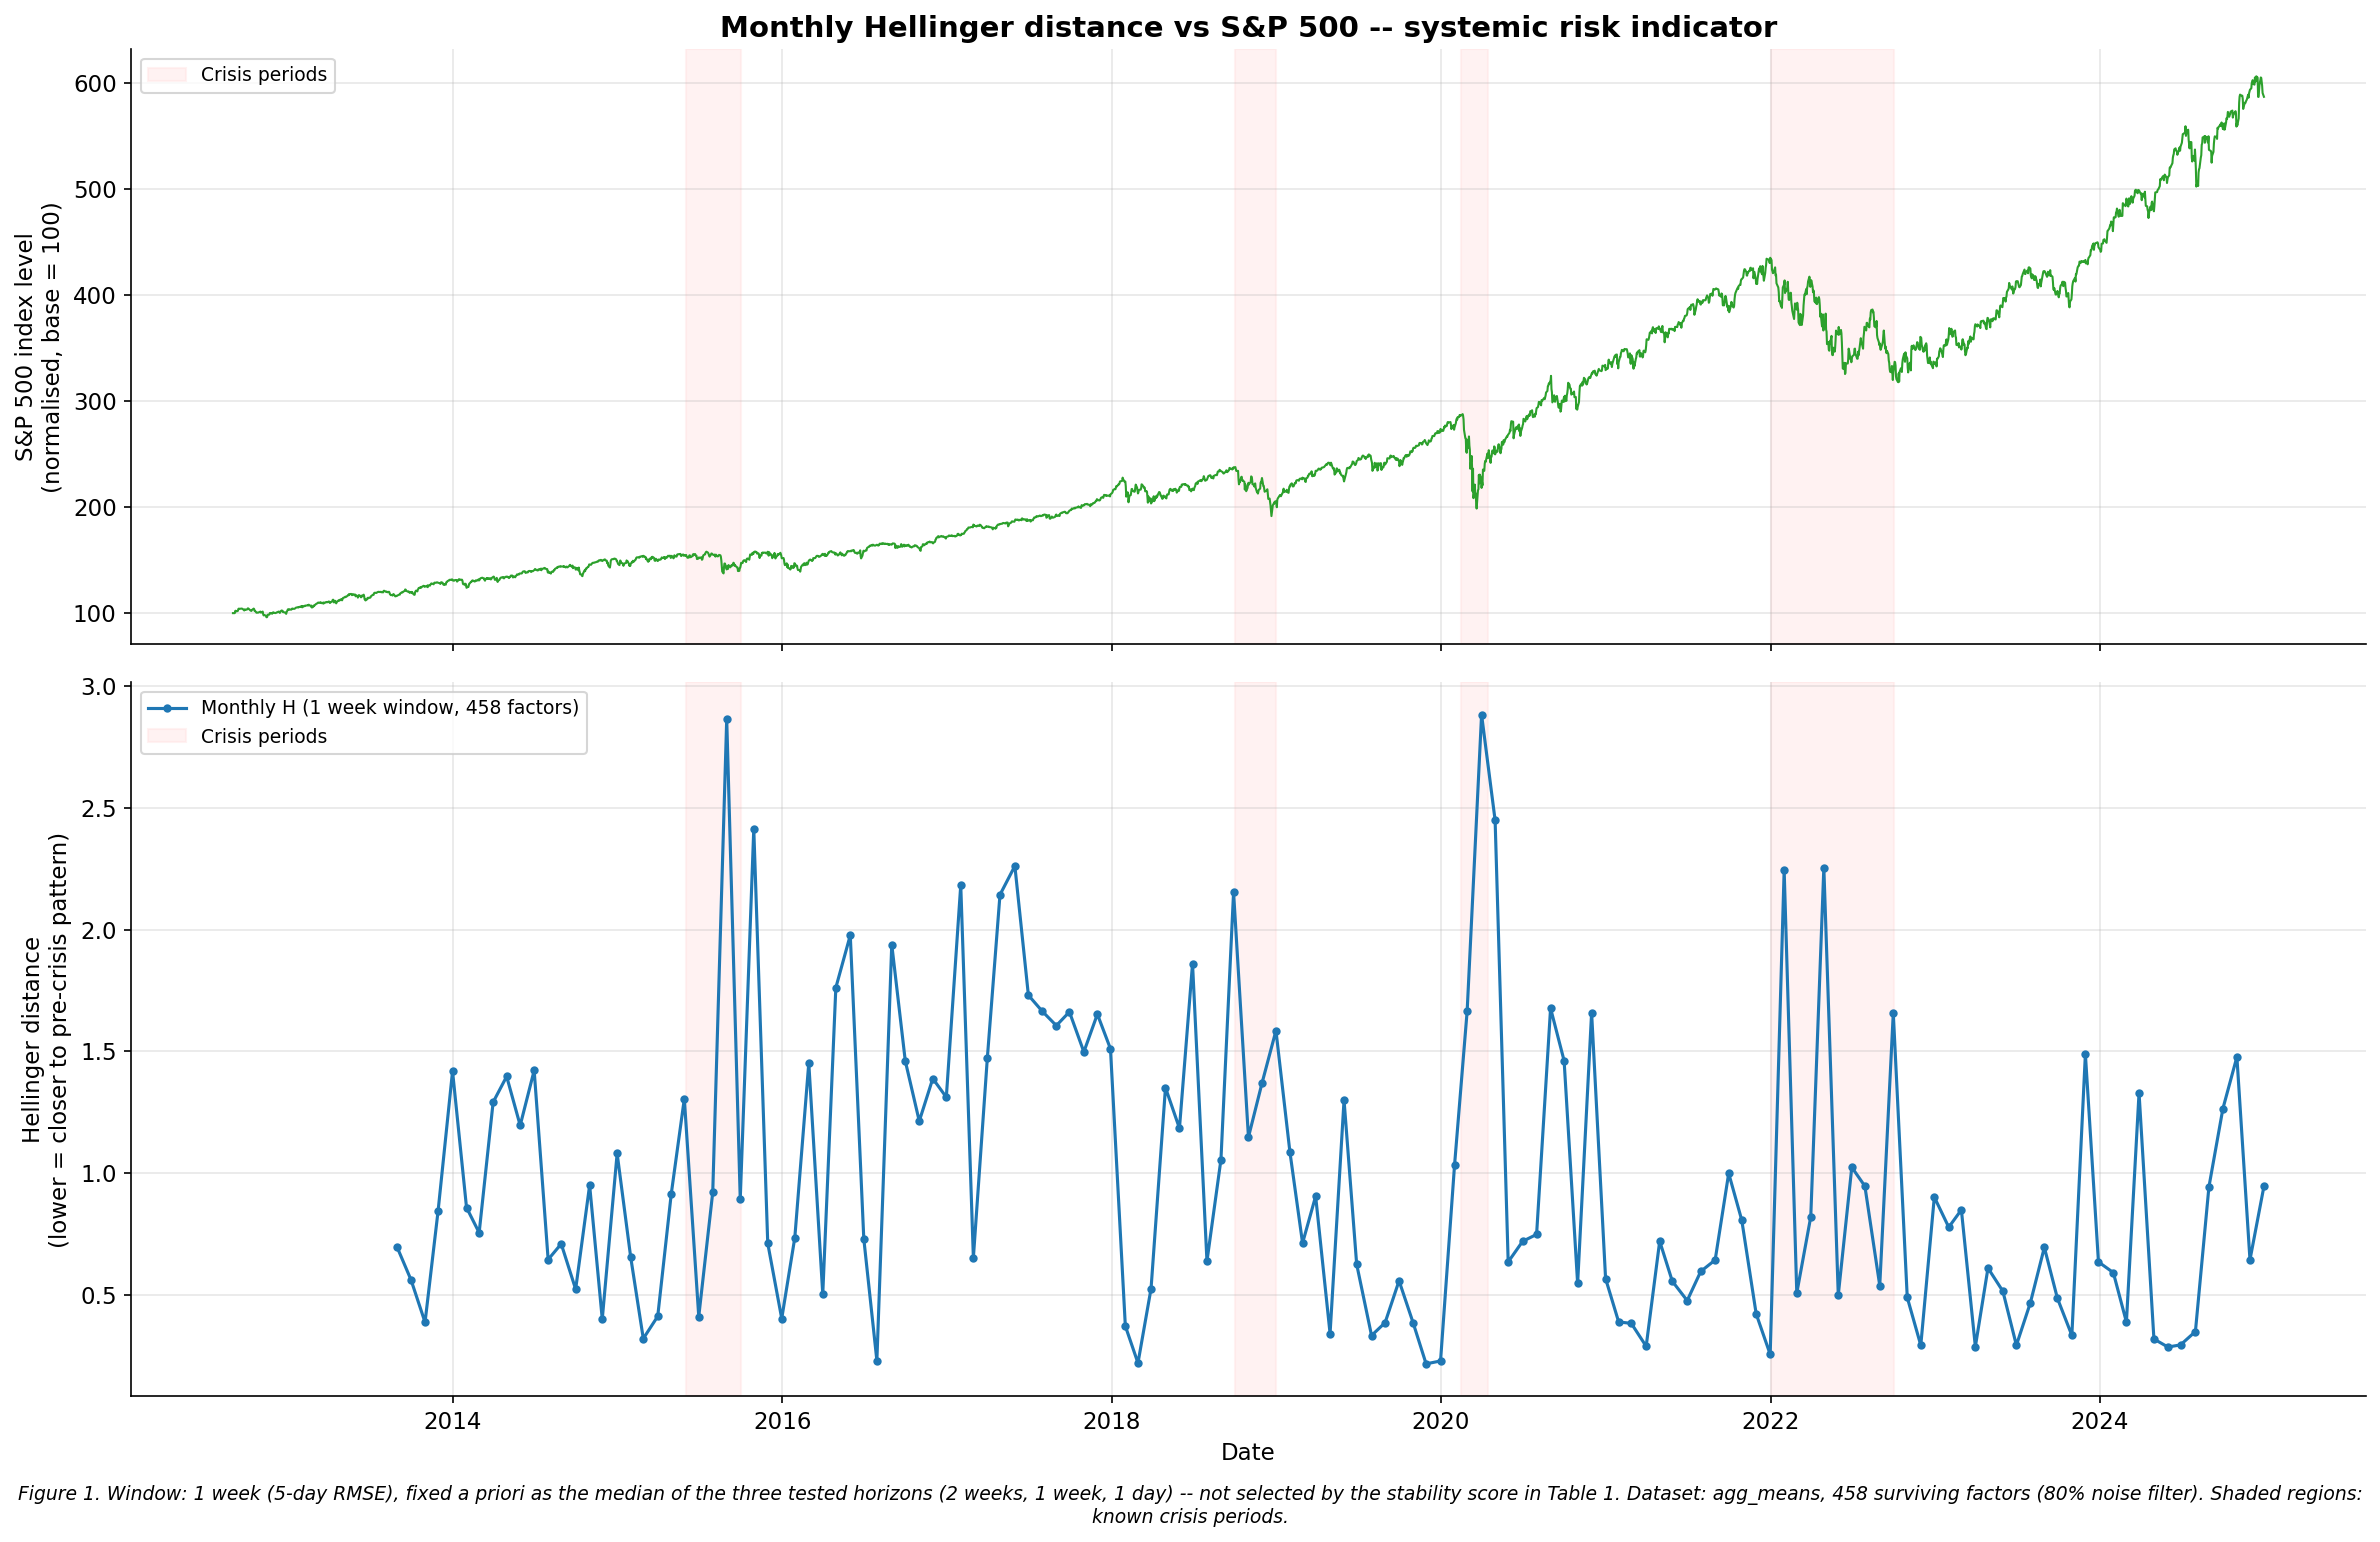

Saved: fig01_monthly_hellinger_agg_means.png
AGGREGATE KDE POLARISATION


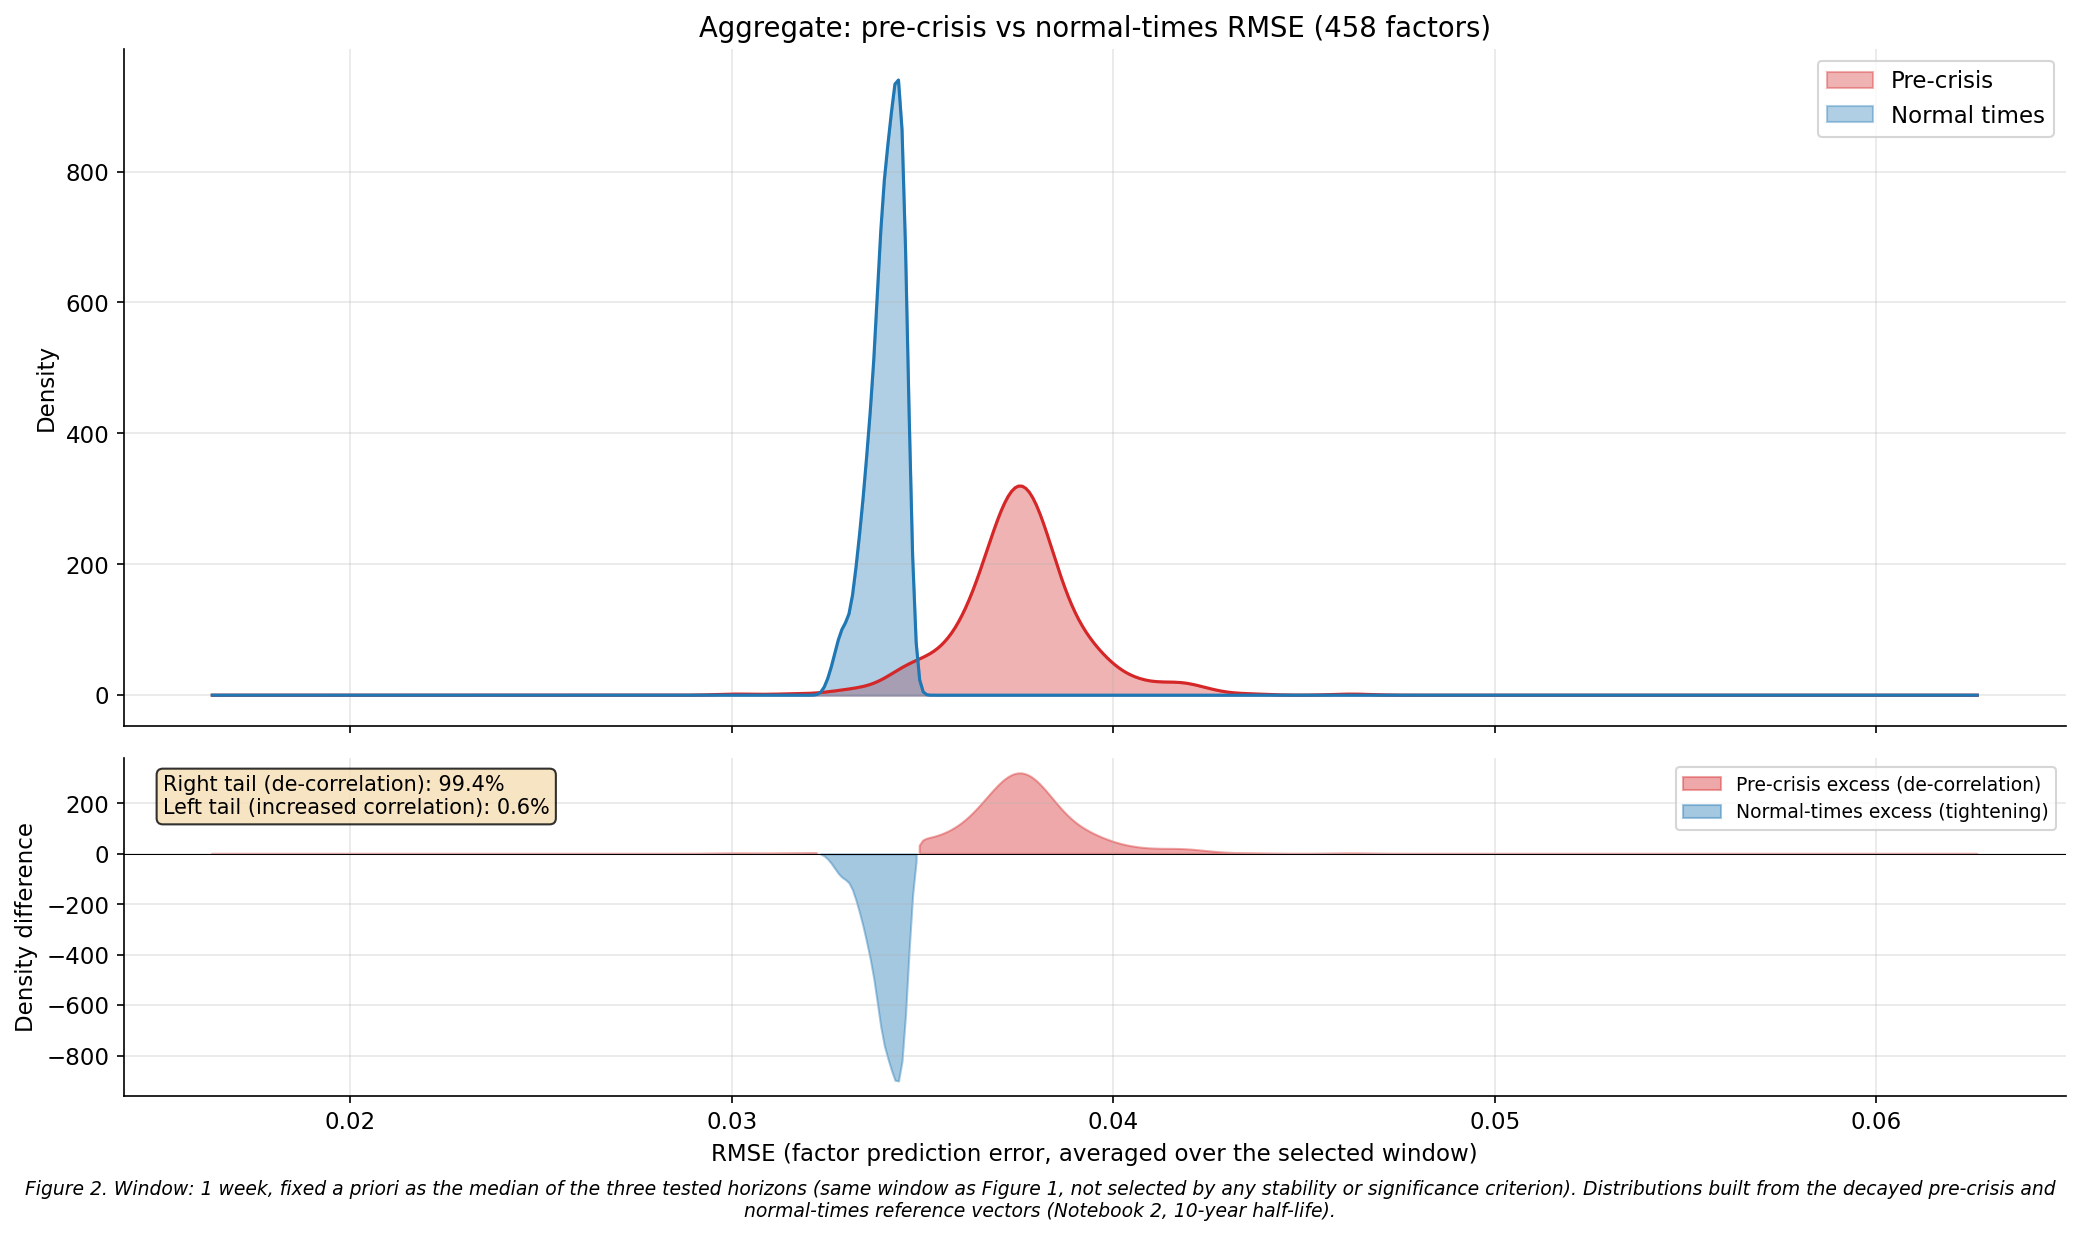

  Aggregate: pre-crisis vs normal-times RMSE (458 factors): right=99.4%, left=0.6%
Themes shown individually (>= 2% of H^2 in some month): 13
Themes merged into 'Other': 0


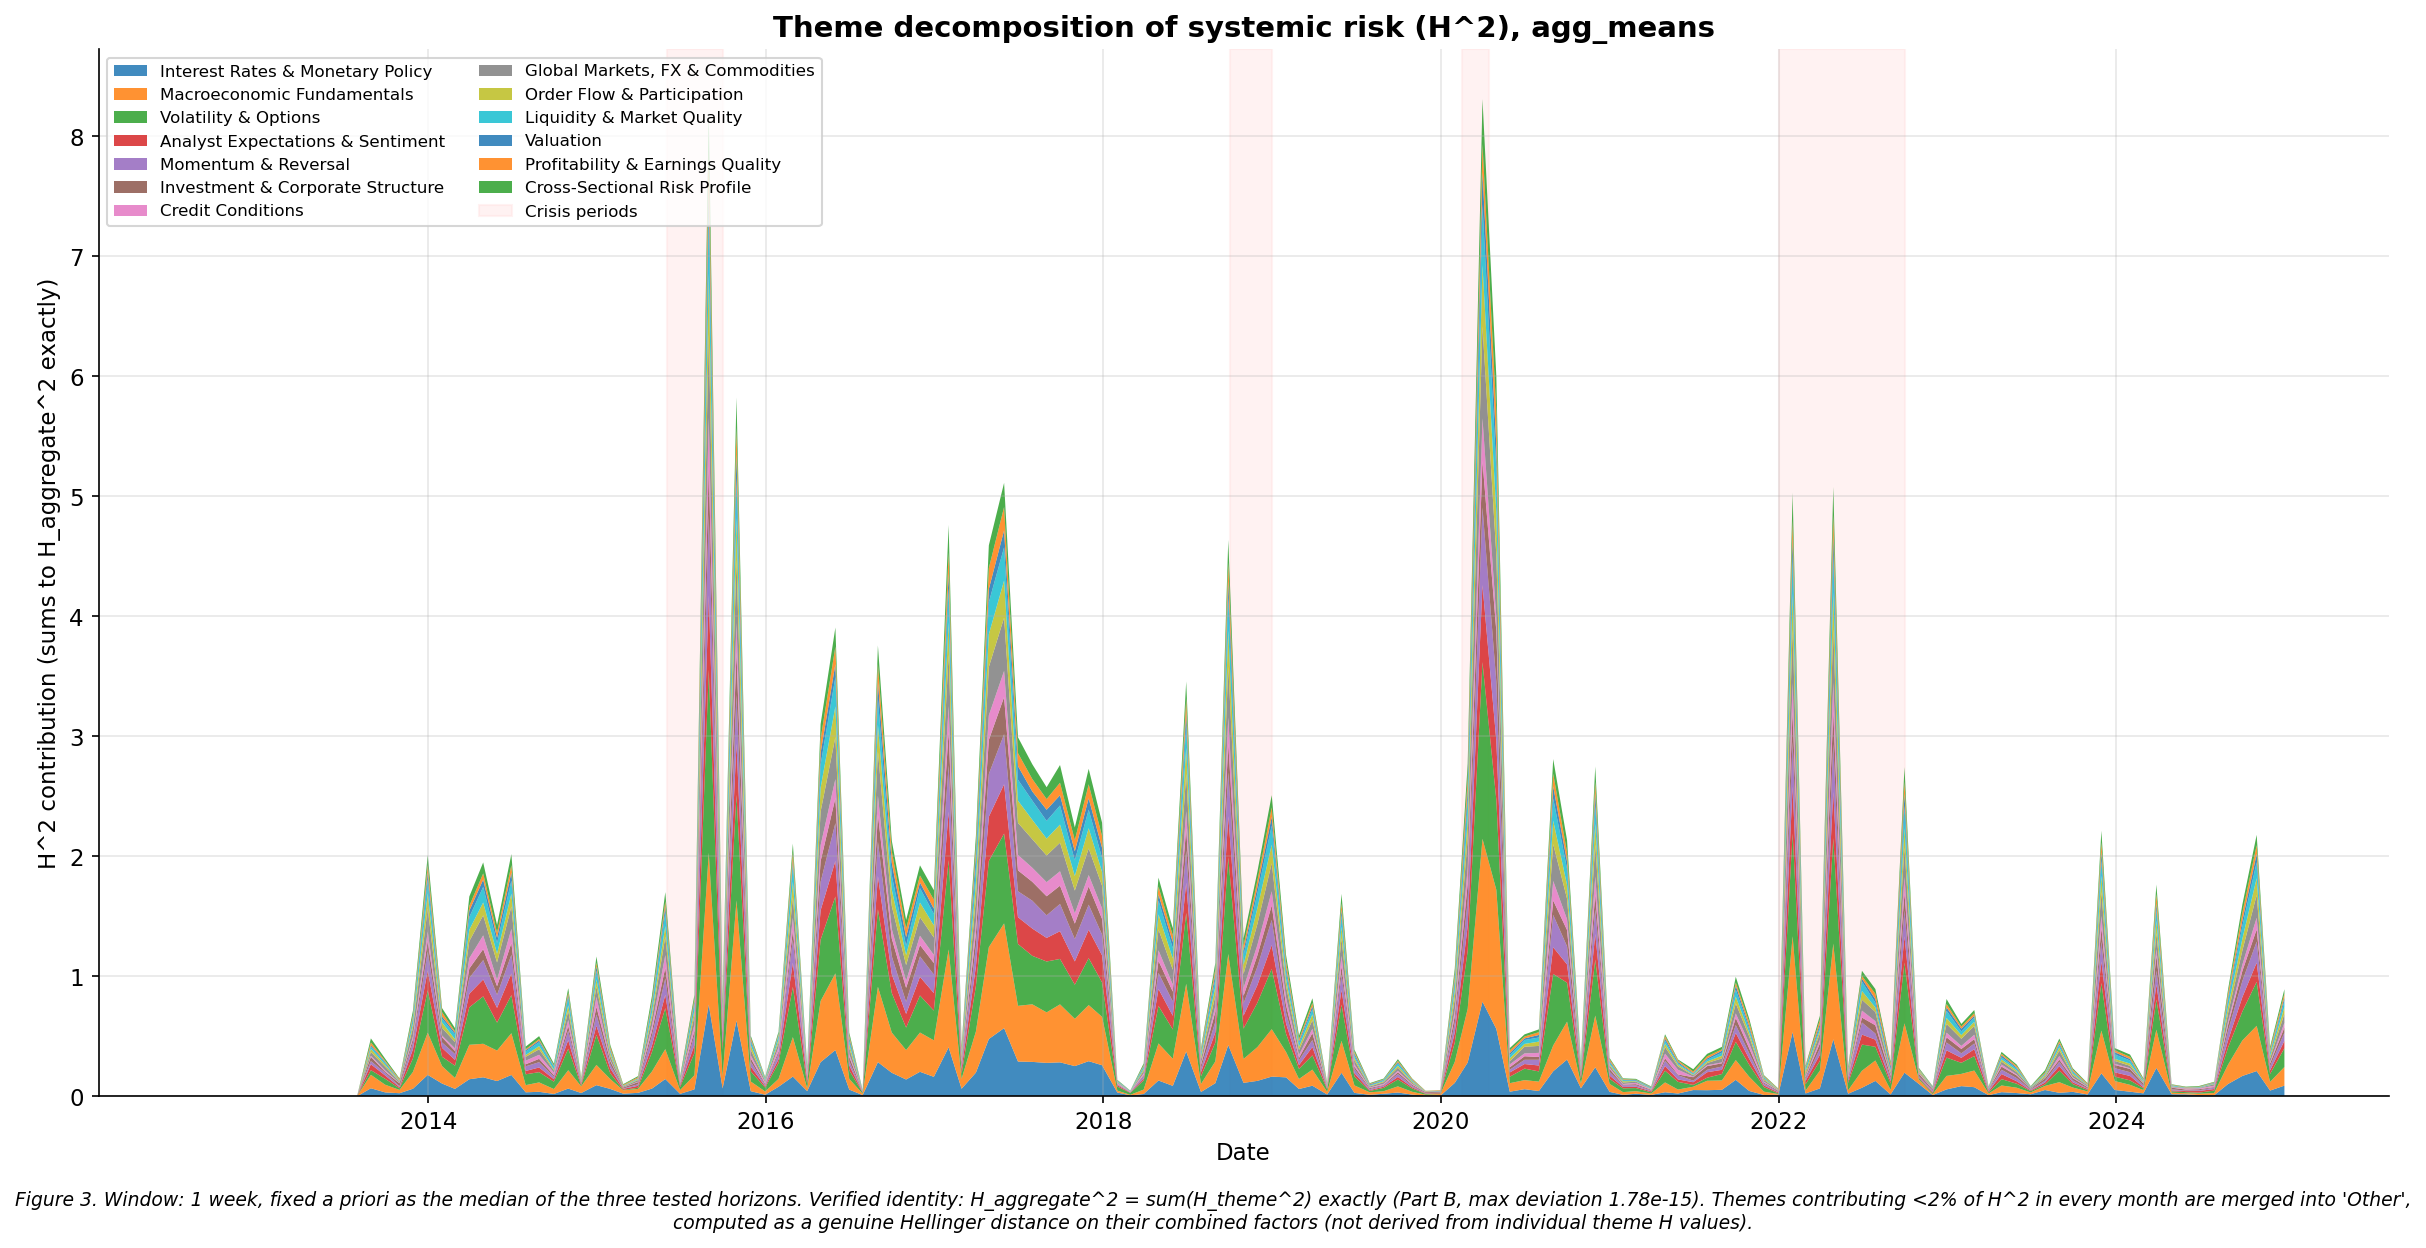

Saved: fig03_theme_decomposition_agg_means.png
TAIL FRACTIONS BY THEME (window=1 week)
                           theme  n_factors  left_tail_pct  right_tail_pct
                       Valuation         14   9.997957e-02        0.900020
Investment & Corporate Structure         24   5.395571e-02        0.946044
Analyst Expectations & Sentiment         35   2.153527e-02        0.978465
Profitability & Earnings Quality         16   1.611607e-02        0.983884
      Macroeconomic Fundamentals         74   1.598996e-02        0.984010
             Momentum & Reversal         36   5.793862e-03        0.994206
      Order Flow & Participation         27   7.706542e-04        0.999229
            Volatility & Options         79   6.238384e-04        0.999376
               Credit Conditions         21   5.813284e-04        0.999419
    Cross-Sectional Risk Profile         20   2.790824e-04        0.999721
Interest Rates & Monetary Policy         45   1.187522e-07        1.000000
      Liquidi

In [1]:
# %% [markdown]
# # Polymodel Results and Figures (Stage 5 Pipeline)
#
# ═══════════════════════════════════════════════════════════════════════
# STRUCTURE
# ═══════════════════════════════════════════════════════════════════════
# Part A: Setup -- load Notebook 2's saved outputs (with a guard confirming
#         the per-window global_fill fix actually landed before proceeding)
# Part B: THE H^2 IDENTITY -- derivation + numerical verification
#         (must run before Part F, since Part F's figure depends on it
#         being true; Part F reuses Part B's per-theme H arrays rather
#         than recomputing them)
# Part C: Window selection for Fig 1 / KDE -- FIXED A PRIORI at 5 days
#         (the median of the three tested horizons), not chosen by the
#         stability criterion. The stability table is still computed and
#         printed for reference, but no longer drives the selection.
# Part D: TABLE 1 -- evaluation window sensitivity (the actual deliverable
#         table: monthly t/p, quarterly t/p, H range, significance stars --
#         printed AND saved, not left implicit inside Part C's selection logic)
# Part E: Fig 1 -- Hellinger distance vs S&P 500
# Part F: Aggregate KDE polarisation
# Part G: Theme H^2 decomposition (stacked area) -- reuses Part B's results
# Part H: Tail-fraction table (themes, ranked)
# Part I: Inter-theme correlation (carries the "do themes add information
#         beyond the aggregate" argument on its own)
#
# ═══════════════════════════════════════════════════════════════════════
# WHAT IS DELIBERATELY NOT HERE, AND WHY
# ═══════════════════════════════════════════════════════════════════════
# - The likelihood-ratio test comparing univariate vs multivariate theme
#   regression: INVALID. H_agg is a nonlinear (Euclidean-norm) function
#   of the theme-level H_k values, so a linear-in-H_agg logit does not
#   nest a linear-in-{H_k} logit -- the LR statistic has no chi-squared
#   reference distribution here.
# - The multivariate regression's AIC/BIC/pseudo-R^2, even reported
#   "for reference": with ~45 quarterly observations against 13+ theme
#   predictors, this fit is exactly the p~n regime the regularisation
#   attempt (also cut) was trying to compensate for. Its diagnostics
#   inherit that instability. Cut entirely.
# - Per-theme and per-subtheme significance tables across every moment
#   type: comfortably 400+ unpenalised tests. Cut. The tail-fraction
#   table (Part H) gives an honest, compact summary instead.
# - 13 individual per-theme KDE plots: replaced by Part H's ranked table.
# - Full noise-filter-sensitivity table (12 rows) and full autocorrelation
#   diagnostic table: already computed and printed in Notebook 2 --
#   referenced in one sentence, not reproduced.
#
# The argument "do themes carry more information than the single
# aggregate H" is carried ENTIRELY by Part I now that the regression
# section is gone -- a correlation-based argument the reader can verify
# at a glance, rather than AIC values from an admittedly unstable
# regression.

DATASET_NAME = "agg_means"   # or "agg_full_moments"

# ==========================================================================
# %% [markdown]
# ## Part A: Setup

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from scipy.stats import gaussian_kde
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# NumPy 2.0 renamed np.trapz to np.trapezoid -- use whichever is present
# so this notebook doesn't crash deep inside a KDE plot on older NumPy.
_trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

ROOT = Path("../..")
RESULTS_ROOT = ROOT / "Data" / "Results" / "Reproducing_Hellinger_Polymodel"
DATA_PM  = RESULTS_ROOT / "intermediate"
FIG_DIR  = RESULTS_ROOT / "figures"
TABLES_DIR = RESULTS_ROOT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (14, 6), "figure.dpi": 150, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

BLUE = "#1f77b4"; GREEN = "#2ca02c"; RED = "#d62728"; GRAY = "#7f7f7f"

CRISES = {
    "2015 China":  ("2015-06-01", "2015-10-01"),
    "2018 Q4":     ("2018-10-01", "2019-01-01"),
    "COVID":       ("2020-02-15", "2020-04-15"),
    "2022 Bear":   ("2022-01-01", "2022-10-01"),
}

def shade_crises(ax):
    first = True
    for name, (s, e) in CRISES.items():
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                   color="#ffe0e0", alpha=0.4, zorder=0,
                   label="Crisis periods" if first else None)
        first = False


def logistic_t_local(signal, fwd_return):
    valid = ~np.isnan(signal) & ~np.isnan(fwd_return)
    if valid.sum() < 30:
        return None
    y = (fwd_return[valid] > 0).astype(float)
    X = sm.add_constant(signal[valid])
    try:
        fit = sm.Logit(y, X).fit(disp=0)
        return {"n": int(valid.sum()), "t": fit.tvalues[1], "p": fit.pvalues[1]}
    except Exception:
        return None


# %%
# ── Load Notebook 2's outputs (dataset-suffixed) ──

hell_path  = DATA_PM / f"hellinger_monthly_{DATASET_NAME}.npz"
rmse_path  = DATA_PM / f"rmse_matrices_{DATASET_NAME}.npz"
target_path = DATA_PM / f"polymodel_target_{DATASET_NAME}.parquet"
feat_path  = DATA_PM / f"polymodel_features_unlagged_{DATASET_NAME}.parquet"
meta_path  = DATA_PM / f"polymodel_feature_meta_{DATASET_NAME}.csv"
params_path = DATA_PM / f"lnlm_params_{DATASET_NAME}.npz"

for p in [hell_path, rmse_path, target_path, feat_path, meta_path, params_path]:
    assert p.exists(), f"Not found: {p} -- run Notebooks 1 and 2 for DATASET_NAME='{DATASET_NAME}' first."

params = np.load(params_path, allow_pickle=True)
param_dates = params["dates"]
feature_names = list(params["feature_names"])
n_months = len(param_dates)
param_dates_ts = pd.DatetimeIndex(param_dates)

hell = np.load(hell_path, allow_pickle=True)
monthly_fwd_63d = hell["monthly_fwd_63d"]
combined_surviving = hell["combined_surviving_idx"]

rmse_data = np.load(rmse_path, allow_pickle=True)

target_df = pd.read_parquet(target_path)
features_df = pd.read_parquet(feat_path)
all_dates = pd.to_datetime(features_df["date"]).values
daily_returns = target_df["daily_return"].values

meta = pd.read_csv(meta_path, dtype={"subtheme_id": str, "theme_id": str})

eval_start = int(np.searchsorted(all_dates, param_dates[0]))

EVAL_WINDOWS = [10, 5, 1]
WINDOW_NAMES = {10: "2 weeks", 5: "1 week", 1: "1 day"}

# ── MANDATORY GUARD: confirm Notebook 2's per-window global_fill fix
# actually landed before proceeding. If this raises, you're running an
# earlier (uncorrected) version of Notebook 2's output -- go back and
# re-run the CORRECTED version (per-window global_fill_10d/5d/1d), not
# an older draft that saved a single unsuffixed "global_fill" key. ──
required_fill_keys = [f"global_fill_{w}d" for w in EVAL_WINDOWS]
missing_keys = [k for k in required_fill_keys if k not in hell.files]
assert not missing_keys, (
    f"Missing key(s) {missing_keys} in {hell_path}. This notebook requires "
    f"a SEPARATE global_fill array per evaluation window (the fix for the "
    f"cross-window imputation bug). Re-run the corrected Notebook 2 -- do "
    f"not proceed against an older, uncorrected output. STOP."
)
print(f"  ✓ Confirmed all per-window global_fill keys present: {required_fill_keys}")

print(f"\nLoaded: {n_months} months, {len(feature_names)} features, "
      f"{len(combined_surviving)} surviving")


# ==========================================================================
# %% [markdown]
# ## Part B: The H^2 Decomposition Identity
#
# ### The claim
# For any partition of the surviving factors into disjoint groups (e.g.
# themes), the SQUARE of the aggregate Hellinger distance equals the sum
# of the squares of each group's own Hellinger distance:
#
#     H_aggregate^2  =  sum over themes k of  H_theme_k^2
#
# ### Why this is true (and what it depends on)
# Section 4.5.1 shows Hellinger distance here reduces algebraically to
# the Euclidean L2 distance between square-root-transformed vectors:
#
#     H = (1/sqrt(2)) * || sqrt(row) - sqrt(R_pre) ||_2
#
# Squared Euclidean distance between two vectors is a SUM OF PER-
# COORDINATE SQUARED TERMS. Any sum of terms indexed by a set splits
# additively across any partition of that index set -- this is a direct,
# mechanical consequence of the metric being additive over coordinates,
# independent of what the coordinates represent or how the reference
# vector R_pre was built.
#
# ### The one real precondition
# Each theme's H_theme_k must be computed as its OWN independent
# Hellinger distance -- with its OWN pc_num/pc_den accumulation running
# only over that theme's factors -- NOT by slicing a pre-computed
# aggregate reference vector down to a theme's coordinates.
#
# ### The only way the identity can fail
# NOT theme size. A theme with exactly 1 factor still contributes
# exactly one coordinate's squared term -- correctly. The identity can
# ONLY fail if a surviving factor is EXCLUDED from every theme group
# used in the check. Accordingly, the verification below uses EVERY
# theme with >=1 surviving factor -- no size filter at this stage.
#
# The per-theme H arrays computed here (at all three windows) are kept
# and reused directly by Part G's figure -- not recomputed there.

# %%
ALPHA_MONTHLY = np.exp(-np.log(2) / 120)
FWD_LAG = 3
alpha_lag = ALPHA_MONTHLY ** FWD_LAG


def compute_hellinger(rmse_matrix, surviving_idx, fwd_returns, fill_matrix,
                      subset_positions=None):
    """
    Identical logic to Notebook 2's compute_hellinger. fill_matrix MUST be
    the fill array computed for THIS SAME evaluation window (Notebook 2's
    global_fill_{w}d) -- using a different window's fill array here would
    reintroduce the cross-window imputation bug fixed in Notebook 2.
    """
    n_surv = len(surviving_idx)
    rmse_sub = rmse_matrix[:, surviving_idx]

    fill_sub = fill_matrix if subset_positions is None else fill_matrix[:, subset_positions]

    pc_num = np.zeros(n_surv); pc_den = 0.0
    nt_num = np.zeros(n_surv); nt_den = 0.0
    H = np.full(len(fwd_returns), np.nan)

    for m in range(len(fwd_returns)):
        pc_num *= ALPHA_MONTHLY; pc_den *= ALPHA_MONTHLY
        nt_num *= ALPHA_MONTHLY; nt_den *= ALPHA_MONTHLY

        row = rmse_sub[m].copy()
        nan_mask = np.isnan(row)
        if nan_mask.any():
            row[nan_mask] = fill_sub[m][nan_mask]

        nt_num += row; nt_den += 1.0

        m_new = m - FWD_LAG
        if m_new >= 0 and not np.isnan(fwd_returns[m_new]) and fwd_returns[m_new] < 0:
            weight = fwd_returns[m_new] ** 2 * alpha_lag
            pc_row = rmse_sub[m_new].copy()
            pc_nan = np.isnan(pc_row)
            if pc_nan.any():
                pc_row[pc_nan] = fill_sub[m_new][pc_nan]
            pc_num += weight * pc_row; pc_den += weight

        if pc_den > 1e-20:
            R_pre = pc_num / pc_den
            diff = np.sqrt(row) - np.sqrt(R_pre)
            H[m] = (1.0 / np.sqrt(2)) * np.sqrt(np.sum(diff ** 2))

    pc_ref = pc_num / pc_den if pc_den > 1e-20 else None
    nt_ref = nt_num / nt_den if nt_den > 1e-20 else None
    return {"H": H, "pc_ref": pc_ref, "nt_ref": nt_ref}


# %%
# ── B.1: Build FULL theme groupings -- every theme, any size, and assert
# every surviving factor is covered exactly once. ──

def build_full_theme_groups(combined_surviving, feature_names, meta):
    full_theme_groups = {}
    theme_display_names = {}

    for pos, idx in enumerate(combined_surviving):
        fname = feature_names[idx]
        match = meta[meta["column"] == fname]
        if len(match) == 0:
            continue
        tid = match.iloc[0]["theme_id"]
        tname = match.iloc[0]["theme_name"]
        full_theme_groups.setdefault(tid, []).append(pos)
        theme_display_names[tid] = tname

    covered = sorted(p for positions in full_theme_groups.values() for p in positions)
    expected = list(range(len(combined_surviving)))
    missing = set(expected) - set(covered)
    assert not missing, (
        f"{len(missing)} surviving factor(s) not assigned to any theme "
        f"(positions: {sorted(missing)[:10]}...) -- the H^2 identity WILL "
        f"fail until every factor is accounted for. Check the taxonomy "
        f"for unassigned columns."
    )
    return full_theme_groups, theme_display_names


full_theme_groups, theme_display_names = build_full_theme_groups(
    combined_surviving, feature_names, meta
)
print(f"Full theme groups built: {len(full_theme_groups)} themes, "
      f"{len(combined_surviving)} factors, every factor covered exactly once")

# %%
# ── B.2: Run the verification at each evaluation window, KEEPING each
# theme's per-window H series for reuse in Part G (no recomputation there). ──

def verify_h_squared_identity(window, rmse_data, monthly_fwd_63d, hell,
                              combined_surviving, full_theme_groups):
    rmse_w = rmse_data[f"rmse_{window}d"]
    fill_w = hell[f"global_fill_{window}d"]
    H_agg = hell[f"H_{window}d"]

    theme_H_series_w = {}
    theme_H_sq_sum = np.zeros_like(H_agg)

    for tid, positions in full_theme_groups.items():
        theme_idx = combined_surviving[positions]
        r = compute_hellinger(rmse_w, theme_idx, monthly_fwd_63d, fill_w,
                              subset_positions=positions)
        H_theme = np.nan_to_num(r["H"], nan=0.0)
        theme_H_series_w[tid] = {"H": H_theme, "pc_ref": r["pc_ref"], "nt_ref": r["nt_ref"]}
        theme_H_sq_sum += H_theme ** 2

    valid = ~np.isnan(H_agg)
    diffs = np.abs(H_agg[valid] ** 2 - theme_H_sq_sum[valid])
    max_diff = diffs.max() if len(diffs) > 0 else np.nan
    is_close = np.allclose(H_agg[valid] ** 2, theme_H_sq_sum[valid], atol=1e-8)

    print(f"  window={window}d: max|H_agg^2 - sum(H_theme^2)| over "
          f"{valid.sum()} valid months = {max_diff:.2e}  ->  "
          f"{'PASS' if is_close else 'FAIL'}")

    return is_close, max_diff, theme_H_sq_sum, theme_H_series_w


print("=" * 80)
print("H^2 IDENTITY VERIFICATION (every theme, all evaluation windows)")
print("=" * 80)

identity_results = {}
for w in EVAL_WINDOWS:
    is_close, max_diff, theme_H_sq_sum, theme_H_series_w = verify_h_squared_identity(
        w, rmse_data, monthly_fwd_63d, hell, combined_surviving, full_theme_groups
    )
    identity_results[w] = {
        "is_close": is_close, "max_diff": max_diff,
        "theme_H_sq_sum": theme_H_sq_sum, "theme_H_series": theme_H_series_w,
    }
    if not is_close:
        print(f"    IDENTITY FAILED at window={w} -- this should not happen "
              f"given B.1's coverage assertion. Investigate before trusting "
              f"Part G's figure.")

all_pass = all(r["is_close"] for r in identity_results.values())
print(f"\nOverall: {'ALL WINDOWS PASS' if all_pass else 'AT LEAST ONE WINDOW FAILED'}")
assert all_pass, "H^2 identity failed for at least one window -- stop and investigate before proceeding to Part G."


# ==========================================================================
# %% [markdown]
# ## Part C: Window Selection for Fig 1 / KDE
#
# The evaluation window used for Figures 1-3 is FIXED A PRIORI at 5 trading
# days (the "1 week" window) -- the median of the three horizons tested
# (2 weeks, 1 week, 1 day). This replaces an earlier version of this
# notebook that picked the window by minimising the gap between monthly and
# quarterly significance. That data-driven rule is defensible in principle
# (Section 4.6.2 frames all three windows as a sensitivity test, not a
# ranked search, and the stability score is not itself a p-value), but it
# still risks the appearance of selecting on outcome, since the same run
# that computes the stability score also computes the significance the
# reader ultimately cares about. Fixing the window in advance removes that
# ambiguity outright.
#
# The stability table is still computed below and printed for reference --
# it remains useful context for interpreting Table 1 in Part D -- but it no
# longer determines SELECTED_WINDOW.

# %%
window_stability = {}
window_stats_cache = {}   # still populated for all windows; used by Part D's Table 1

for w in EVAL_WINDOWS:
    H = hell[f"H_{w}d"]
    lg_m = logistic_t_local(H, monthly_fwd_63d)

    q_ts = []; q_ps = []
    for offset in range(3):
        q_idx = np.arange(offset, n_months, 3)
        lg_q = logistic_t_local(H[q_idx], monthly_fwd_63d[q_idx])
        if lg_q:
            q_ts.append(lg_q["t"]); q_ps.append(lg_q["p"])

    window_stats_cache[w] = {"lg_m": lg_m, "q_ts": q_ts, "q_ps": q_ps}

    if lg_m and len(q_ps) == 3:
        avg_qp = np.mean(q_ps)
        stability_score = abs(lg_m["p"] - avg_qp)
        window_stability[w] = {"monthly_p": lg_m["p"], "quarterly_p": avg_qp,
                               "stability_score": stability_score}

print("Window stability (reported for reference only -- does NOT determine "
      "the selected window below):")
for w, v in window_stability.items():
    print(f"  {WINDOW_NAMES[w]:10s}: monthly_p={v['monthly_p']:.4f}  "
          f"quarterly_p={v['quarterly_p']:.4f}  "
          f"stability_score={v['stability_score']:.4f}")

# ── Fixed a priori. Not derived from window_stability above. ──
SELECTED_WINDOW = 5

print(f"\nSelected window for Fig 1 / KDE: {SELECTED_WINDOW}d "
      f"({WINDOW_NAMES[SELECTED_WINDOW]}) -- fixed a priori as the median "
      f"of the three tested horizons (2 weeks, 1 week, 1 day). This choice "
      f"is independent of the stability scores printed above.")


# %%
# ── C-SRI: Douady's exact regressor, SRI_t = 1{H_t < H_(t-1)} ──
# Predicts D_t = 1{r_{t->t+63} > 0} directly on the binary momentum flag
# rather than the level of H_t. This discards the magnitude of the change
# and loses one further observation (SRI is undefined at the first valid
# H), but is the literal specification in Barrau & Douady's Eq. 4.4.
# Reported as a robustness check alongside the level regression, not a
# replacement for it — see Section 3.6.1.

window_stats_cache_sri = {}

for w in EVAL_WINDOWS:
    SRI = hell[f"SRI_{w}d"]
    lg_m = logistic_t_local(SRI, monthly_fwd_63d)

    q_ts = []; q_ps = []
    for offset in range(3):
        q_idx = np.arange(offset, n_months, 3)
        lg_q = logistic_t_local(SRI[q_idx], monthly_fwd_63d[q_idx])
        if lg_q:
            q_ts.append(lg_q["t"]); q_ps.append(lg_q["p"])

    window_stats_cache_sri[w] = {"lg_m": lg_m, "q_ts": q_ts, "q_ps": q_ps}

# %%
table1_sri_rows = []
for w in EVAL_WINDOWS:
    cached = window_stats_cache_sri[w]
    lg_m, q_ts, q_ps = cached["lg_m"], cached["q_ts"], cached["q_ps"]

    m_t = lg_m["t"] if lg_m else np.nan
    m_p = lg_m["p"] if lg_m else np.nan
    q_t = np.mean(q_ts) if len(q_ts) == 3 else np.nan
    q_p = np.mean(q_ps) if len(q_ps) == 3 else np.nan

    star = ""
    if not np.isnan(q_p):
        star = "***" if q_p < 0.01 else "**" if q_p < 0.05 else "*" if q_p < 0.10 else ""

    table1_sri_rows.append({
        "window": WINDOW_NAMES[w], "window_days": w,
        "monthly_t": m_t, "monthly_p": m_p,
        "quarterly_t": q_t, "quarterly_p": q_p,
        "significance": star,
    })

table1_sri_df = pd.DataFrame(table1_sri_rows)

print("=" * 95)
print(f"TABLE 1b: BINARY SRI SPECIFICATION (Douady's exact regressor, {DATASET_NAME})")
print("  SRI_t = 1{H_t < H_(t-1)}; predicted sign is NEGATIVE (opposite of the")
print("  level regression's positive prediction — see Section 3.6.1)")
print("=" * 95)
print(f"\n  {'Window':12s} {'Monthly t':>10s} {'Monthly p':>10s} "
      f"{'Quarterly t':>12s} {'Quarterly p':>12s}")
print(f"  {'-' * 60}")
for _, r in table1_sri_df.iterrows():
    print(f"  {r['window']:12s} {r['monthly_t']:+10.3f} {r['monthly_p']:10.4f} "
          f"{r['quarterly_t']:+12.3f} {r['quarterly_p']:12.4f} {r['significance']}")

table1_sri_df.to_csv(TABLES_DIR / f"table1b_sri_specification_{DATASET_NAME}.csv", index=False)
print(f"\nSaved: table1b_sri_specification_{DATASET_NAME}.csv")


# ==========================================================================
# %% [markdown]
# ## Part D: Table 1 -- Evaluation Window Sensitivity (the deliverable table)
#
# **What this table shows:** for each of the three evaluation windows,
# whether the aggregate Hellinger distance H significantly predicts the
# DIRECTION of the 3-month-ahead market return, tested two ways: monthly
# sampling (n~134, some overlap between consecutive 63-day forward
# returns) and quarterly sampling (n~45, zero overlap, averaged across 3
# non-overlapping offsets to avoid cherry-picking a start date). The H
# range column shows the min/max value H actually took across the sample
# period, for scale. This is a single, pre-specified test -- reported
# honestly with its own p-value, not one of many unpenalised comparisons.

# %%
table1_rows = []
for w in EVAL_WINDOWS:
    H = hell[f"H_{w}d"]
    cached = window_stats_cache[w]
    lg_m = cached["lg_m"]
    q_ts = cached["q_ts"]
    q_ps = cached["q_ps"]

    m_t = lg_m["t"] if lg_m else np.nan
    m_p = lg_m["p"] if lg_m else np.nan
    q_t = np.mean(q_ts) if len(q_ts) == 3 else np.nan
    q_p = np.mean(q_ps) if len(q_ps) == 3 else np.nan

    star = ""
    if not np.isnan(q_p):
        star = "***" if q_p < 0.01 else "**" if q_p < 0.05 else "*" if q_p < 0.10 else ""

    h_min, h_max = np.nanmin(H), np.nanmax(H)

    table1_rows.append({
        "window": WINDOW_NAMES[w], "window_days": w,
        "monthly_t": m_t, "monthly_p": m_p,
        "quarterly_t": q_t, "quarterly_p": q_p,
        "h_min": h_min, "h_max": h_max, "significance": star,
    })

table1_df = pd.DataFrame(table1_rows)

print("=" * 95)
print(f"TABLE 1: EVALUATION WINDOW SENSITIVITY ({DATASET_NAME})")
print("  Monthly: n ~ 134 (some overlap in 63-day forward returns)")
print("  Quarterly: n ~ 45 (zero overlap, average of 3 offsets)")
print("  Stars: *** p<0.01  ** p<0.05  * p<0.10")
print("=" * 95)
print(f"\n  {'Window':12s} {'Monthly t':>10s} {'Monthly p':>10s} "
      f"{'Quarterly t':>12s} {'Quarterly p':>12s} {'H range':>20s}")
print(f"  {'-' * 80}")
for _, r in table1_df.iterrows():
    h_range = f"[{r['h_min']:.3f}, {r['h_max']:.3f}]"
    print(f"  {r['window']:12s} {r['monthly_t']:+10.3f} {r['monthly_p']:10.4f} "
          f"{r['quarterly_t']:+12.3f} {r['quarterly_p']:12.4f} "
          f"{h_range:>20s} {r['significance']}")

table1_df.to_csv(TABLES_DIR / f"table1_window_sensitivity_{DATASET_NAME}.csv", index=False)
print(f"\nSaved: table1_window_sensitivity_{DATASET_NAME}.csv")


# ==========================================================================
# %% [markdown]
# ## Part E: Fig 1 -- Monthly Hellinger Distance vs S&P 500
#
# **What this figure shows:** the top panel plots the S&P 500 level
# (normalised to 100 at the start of the evaluation period) so crisis
# periods are visible directly in the price series. The bottom panel
# plots the monthly Hellinger distance H(t) at the window fixed in
# Part C -- a LOWER value of H means the current month's cross-section
# of factor prediction errors looks MORE like the historical pre-crisis
# reference pattern (i.e. more "at risk"); a HIGHER value means it looks
# more like ordinary, normal-times behaviour. Red shaded bands mark four
# known crisis periods for visual cross-reference against both panels.

# %%
spx_price = 100 * np.cumprod(1 + daily_returns[eval_start:])
spx_dates = pd.DatetimeIndex(all_dates[eval_start:])

H_selected = hell[f"H_{SELECTED_WINDOW}d"]

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(16, 10), sharex=True,
    gridspec_kw={"height_ratios": [1, 1.2]}
)

ax_top.plot(spx_dates, spx_price, color=GREEN, linewidth=1)
shade_crises(ax_top)
ax_top.set_ylabel("S&P 500 index level\n(normalised, base = 100)")
ax_top.set_title("Monthly Hellinger distance vs S&P 500 -- systemic risk indicator",
                  fontsize=14, fontweight="bold")
ax_top.legend(loc="upper left", fontsize=9)

ax_bot.plot(param_dates_ts, H_selected, color=BLUE,
            linewidth=1.5, marker="o", markersize=3,
            label=f"Monthly H ({WINDOW_NAMES[SELECTED_WINDOW]} window, "
                  f"{len(combined_surviving)} factors)")
shade_crises(ax_bot)
ax_bot.set_ylabel("Hellinger distance\n(lower = closer to pre-crisis pattern)")
ax_bot.set_xlabel("Date")
ax_bot.legend(loc="upper left", fontsize=9)
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.text(0.5, -0.02,
         f"Figure 1. Window: {WINDOW_NAMES[SELECTED_WINDOW]} ({SELECTED_WINDOW}-day RMSE), "
         f"fixed a priori as the median of the three tested horizons "
         f"(2 weeks, 1 week, 1 day) -- not selected by the stability score in "
         f"Table 1. Dataset: {DATASET_NAME}, {len(combined_surviving)} surviving "
         f"factors (80% noise filter). Shaded regions: known crisis periods.",
         ha="center", fontsize=9, style="italic", wrap=True)

plt.tight_layout()
plt.savefig(FIG_DIR / f"fig01_monthly_hellinger_{DATASET_NAME}.png",
           dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: fig01_monthly_hellinger_{DATASET_NAME}.png")


# ==========================================================================
# %% [markdown]
# ## Part F: Aggregate KDE Polarisation
#
# **What this figure shows:** two overlapping density curves -- the
# distribution of individual factors' RMSE values during pre-crisis
# months (red) versus normal-times months (blue), at the window fixed
# in Part C. The bottom panel is the DIFFERENCE between these two
# densities: red-shaded regions (right of the median) show where
# pre-crisis RMSE values occur MORE often than normal-times RMSE values
# ("de-correlation" -- factors predicting worse before crises); blue-
# shaded regions (left of the median) show the opposite ("tightening" --
# factors predicting better before crises).

# %%
def plot_polarisation(pc_ref, nt_ref, title, filename, caption_extra=""):
    all_v = np.concatenate([pc_ref, nt_ref])
    lo, hi = np.percentile(all_v, [1, 99])
    grid = np.linspace(lo * 0.5, hi * 1.5, 500)

    kpc = gaussian_kde(pc_ref, bw_method="silverman")(grid)
    knt = gaussian_kde(nt_ref, bw_method="silverman")(grid)
    diff = kpc - knt

    fig, (a1, a2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                  gridspec_kw={"height_ratios": [2, 1]})

    a1.fill_between(grid, kpc, alpha=0.35, color=RED, label="Pre-crisis")
    a1.fill_between(grid, knt, alpha=0.35, color=BLUE, label="Normal times")
    a1.plot(grid, kpc, color=RED, lw=1.5); a1.plot(grid, knt, color=BLUE, lw=1.5)
    a1.set_ylabel("Density"); a1.set_title(title); a1.legend()

    a2.fill_between(grid, diff, where=diff > 0, color=RED, alpha=0.4,
                     label="Pre-crisis excess (de-correlation)")
    a2.fill_between(grid, diff, where=diff < 0, color=BLUE, alpha=0.4,
                     label="Normal-times excess (tightening)")
    a2.axhline(0, color="k", lw=0.5)
    a2.set_xlabel("RMSE (factor prediction error, averaged over the selected window)")
    a2.set_ylabel("Density difference"); a2.legend(fontsize=9)

    mid = np.median(all_v)
    r_ex = _trapz(np.maximum(diff[grid > mid], 0), grid[grid > mid])
    l_ex = _trapz(np.maximum(diff[grid <= mid], 0), grid[grid <= mid])
    tot = r_ex + l_ex
    if tot > 0:
        a2.text(0.02, 0.95,
                f"Right tail (de-correlation): {r_ex/tot:.1%}\n"
                f"Left tail (increased correlation): {l_ex/tot:.1%}",
                transform=a2.transAxes, fontsize=10, va="top",
                bbox=dict(boxstyle="round", fc="wheat", alpha=0.8))

    fig.text(0.5, -0.02, caption_extra, ha="center", fontsize=9, style="italic", wrap=True)

    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    if tot > 0:
        print(f"  {title}: right={r_ex/tot:.1%}, left={l_ex/tot:.1%}")
    return (r_ex / tot, l_ex / tot) if tot > 0 else (np.nan, np.nan)


print("=" * 70)
print("AGGREGATE KDE POLARISATION")
print("=" * 70)

agg_right, agg_left = plot_polarisation(
    hell[f"pcref_{SELECTED_WINDOW}d"],
    hell[f"ntref_{SELECTED_WINDOW}d"],
    f"Aggregate: pre-crisis vs normal-times RMSE ({len(combined_surviving)} factors)",
    f"fig02_aggregate_kde_{DATASET_NAME}.png",
    caption_extra=(
        f"Figure 2. Window: {WINDOW_NAMES[SELECTED_WINDOW]}, fixed a priori "
        f"as the median of the three tested horizons (same window as "
        f"Figure 1, not selected by any stability or significance criterion). "
        f"Distributions built from the decayed pre-crisis and normal-times "
        f"reference vectors (Notebook 2, 10-year half-life)."
    )
)


# ==========================================================================
# %% [markdown]
# ## Part G: Theme H^2 Decomposition (Stacked Area)
#
# **What this figure shows:** for every month, the SQUARED aggregate
# Hellinger distance H_agg(t)^2 is broken into contributions from each
# theme, stacked on top of each other -- so the total height of the
# stack at any point in time equals H_agg(t)^2 exactly (verified in
# Part B). Each colored band's thickness shows how much that theme
# contributed to systemic risk at that moment. Themes contributing a
# visually negligible share throughout are merged into a single grey
# "Other" band -- computed as a genuine Hellinger distance on the UNION
# of those themes' factors (not backed out algebraically from their
# individual H values, since only H^2, not H itself, is additive).
#
# This reuses Part B's already-computed per-theme H series at the
# selected window rather than recomputing them.

# %%
DISPLAY_MIN_SHARE = 0.02  # visual threshold only -- does not affect Part B's identity

theme_H_series_selected = identity_results[SELECTED_WINDOW]["theme_H_series"]
H_agg_selected = hell[f"H_{SELECTED_WINDOW}d"]
H_agg_sq = H_agg_selected ** 2

theme_share_max = {}
for tid, positions in full_theme_groups.items():
    H_theme = theme_H_series_selected[tid]["H"]
    valid = ~np.isnan(H_agg_sq) & (H_agg_sq > 1e-12)
    if valid.any():
        share = (H_theme[valid] ** 2) / H_agg_sq[valid]
        theme_share_max[tid] = np.nanmax(share)
    else:
        theme_share_max[tid] = 0.0

display_themes = [tid for tid, s in theme_share_max.items() if s >= DISPLAY_MIN_SHARE]
other_themes = [tid for tid, s in theme_share_max.items() if s < DISPLAY_MIN_SHARE]

print(f"Themes shown individually (>= {DISPLAY_MIN_SHARE:.0%} of H^2 in some month): "
      f"{len(display_themes)}")
print(f"Themes merged into 'Other': {len(other_themes)}")

# "Other" band: a GENUINE Hellinger distance on the union of small themes'
# factor positions -- not derived algebraically from individual H values.
rmse_selected = rmse_data[f"rmse_{SELECTED_WINDOW}d"]
fill_selected = hell[f"global_fill_{SELECTED_WINDOW}d"]

if other_themes:
    other_positions = [p for tid in other_themes for p in full_theme_groups[tid]]
    other_idx = combined_surviving[other_positions]
    r_other = compute_hellinger(rmse_selected, other_idx, monthly_fwd_63d, fill_selected,
                                subset_positions=other_positions)
    other_H_sq = np.nan_to_num(r_other["H"], nan=0.0) ** 2
else:
    other_H_sq = np.zeros(n_months)

# %%
stack_data = []
stack_labels = []
for tid in sorted(display_themes, key=lambda t: -theme_share_max[t]):
    stack_data.append(theme_H_series_selected[tid]["H"] ** 2)
    stack_labels.append(theme_display_names[tid])

if other_themes:
    stack_data.append(other_H_sq)
    stack_labels.append(f"Other ({len(other_themes)} themes)")

fig, ax = plt.subplots(figsize=(16, 8))
ax.stackplot(param_dates_ts, *stack_data, labels=stack_labels, alpha=0.85)
shade_crises(ax)
ax.set_ylabel("H^2 contribution (sums to H_aggregate^2 exactly)")
ax.set_xlabel("Date")
ax.set_title(f"Theme decomposition of systemic risk (H^2), {DATASET_NAME}",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.text(0.5, -0.03,
         f"Figure 3. Window: {WINDOW_NAMES[SELECTED_WINDOW]}, fixed a priori "
         f"as the median of the three tested horizons. Verified identity: "
         f"H_aggregate^2 = sum(H_theme^2) exactly (Part B, max deviation "
         f"{identity_results[SELECTED_WINDOW]['max_diff']:.2e}). Themes contributing "
         f"<{DISPLAY_MIN_SHARE:.0%} of H^2 in every month are merged into 'Other', "
         f"computed as a genuine Hellinger distance on their combined factors "
         f"(not derived from individual theme H values).",
         ha="center", fontsize=9, style="italic", wrap=True)

plt.tight_layout()
plt.savefig(FIG_DIR / f"fig03_theme_decomposition_{DATASET_NAME}.png",
           dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: fig03_theme_decomposition_{DATASET_NAME}.png")


# ==========================================================================
# %% [markdown]
# ## Part H: Tail-Fraction Table (Themes, Ranked)
#
# **What this table shows:** for each theme, what fraction of the
# pre-crisis-vs-normal-times density DIFFERENCE (same computation as
# Figure 2's aggregate version, applied per theme) falls in the "left
# tail" (theme predicts BETTER before crises) versus "right tail" (theme
# predicts WORSE before crises). Ranked by left-tail fraction, largest
# first. Reuses Part B's per-theme reference vectors at the selected
# window -- not recomputed here.

# %%
def tail_fractions(pc_ref, nt_ref):
    if pc_ref is None or nt_ref is None or len(pc_ref) == 0:
        return np.nan, np.nan
    all_v = np.concatenate([pc_ref, nt_ref])
    mid = np.median(all_v)
    lo, hi = np.percentile(all_v, [1, 99])
    grid = np.linspace(lo * 0.5, hi * 1.5, 500)
    kpc = gaussian_kde(pc_ref, bw_method="silverman")(grid)
    knt = gaussian_kde(nt_ref, bw_method="silverman")(grid)
    diff = kpc - knt
    r_ex = _trapz(np.maximum(diff[grid > mid], 0), grid[grid > mid])
    l_ex = _trapz(np.maximum(diff[grid <= mid], 0), grid[grid <= mid])
    tot = r_ex + l_ex
    return (r_ex / tot, l_ex / tot) if tot > 0 else (np.nan, np.nan)


tail_rows = []
for tid, positions in full_theme_groups.items():
    r_pc = theme_H_series_selected[tid]["pc_ref"]
    r_nt = theme_H_series_selected[tid]["nt_ref"]
    r_pct, l_pct = tail_fractions(r_pc, r_nt)
    tail_rows.append({
        "theme": theme_display_names[tid], "n_factors": len(positions),
        "left_tail_pct": l_pct, "right_tail_pct": r_pct,
    })

tail_df = pd.DataFrame(tail_rows).dropna(subset=["left_tail_pct"])
tail_df = tail_df.sort_values("left_tail_pct", ascending=False)

print("=" * 80)
print(f"TAIL FRACTIONS BY THEME (window={WINDOW_NAMES[SELECTED_WINDOW]})")
print("=" * 80)
print(tail_df.to_string(index=False))

tail_df.to_csv(TABLES_DIR / f"table_tail_fractions_{DATASET_NAME}.csv", index=False)
print(f"\nSaved: table_tail_fractions_{DATASET_NAME}.csv")


# ==========================================================================
# %% [markdown]
# ## Part I: Inter-Theme Correlation
#
# **What this measures, and why it now carries the full argument:** the
# multivariate theme-regression comparison has been cut entirely -- with
# ~45 quarterly observations against 13+ predictors, that fit is
# unstable, and its AIC/BIC/pseudo-R^2 would inherit that instability
# even reported descriptively. The question those diagnostics were meant
# to answer -- "do themes carry more information than the single
# aggregate H" -- is answered here instead: if themes are highly
# correlated, they move together and the aggregate captures most of what
# any one would show individually. If weakly correlated, they carry
# distinct information the aggregate discards by averaging over all of
# them equally.

# %%
q_idx = np.arange(0, n_months, 3)  # quarterly sampling, zero overlap
theme_ids_sorted = sorted(full_theme_groups.keys())

theme_H_matrix_q = np.column_stack([
    theme_H_series_selected[tid]["H"][q_idx] for tid in theme_ids_sorted
])

valid_rows = ~np.any(np.isnan(theme_H_matrix_q), axis=1)
theme_corr = np.corrcoef(theme_H_matrix_q[valid_rows].T)

avg_corr = theme_corr[np.triu_indices_from(theme_corr, k=1)].mean()
min_corr = theme_corr[np.triu_indices_from(theme_corr, k=1)].min()
max_corr = theme_corr[np.triu_indices_from(theme_corr, k=1)].max()

print("=" * 75)
print(f"INTER-THEME HELLINGER CORRELATION (quarterly, n={valid_rows.sum()})")
print("=" * 75)
print(f"\n  Average pairwise correlation: {avg_corr:.2f}")
print(f"  Range:                        [{min_corr:.2f}, {max_corr:.2f}]")

if avg_corr > 0.8:
    interpretation = (
        "High inter-theme correlation means themes move together closely -- "
        "the aggregate H captures most of what any single theme's Hellinger "
        "distance would show. Equal-weight aggregation loses relatively "
        "little information in this regime."
    )
elif avg_corr < 0.5:
    interpretation = (
        "Low inter-theme correlation means themes carry substantially "
        "independent information -- no single aggregate score can represent "
        "all of them well, which motivates examining themes separately "
        "rather than relying on the aggregate alone."
    )
else:
    interpretation = (
        "Moderate inter-theme correlation -- some independent information "
        "exists across themes, but it is partially redundant with the "
        "aggregate signal."
    )

print(f"\n  {interpretation}")

with open(TABLES_DIR / f"theme_correlation_summary_{DATASET_NAME}.txt", "w") as f:
    f.write(f"Average pairwise correlation: {avg_corr:.4f}\n")
    f.write(f"Range: [{min_corr:.4f}, {max_corr:.4f}]\n")
    f.write(f"n (quarterly observations): {valid_rows.sum()}\n\n")
    f.write(interpretation)

print(f"\nSaved: theme_correlation_summary_{DATASET_NAME}.txt")

print("\n" + "=" * 70)
print("NOTEBOOK 3 COMPLETE")
print("=" * 70)
print(f"  Figures: {FIG_DIR}")
print(f"  Tables:  {TABLES_DIR}")

In [2]:
from scipy.stats import spearmanr

themes = ["Valuation", "Investment & Corp Structure", "Analyst Expectations & Sentiment",
          "Profitability & Earnings Quality", "Macroeconomic Fundamentals",
          "Momentum & Reversal", "Order Flow & Participation", "Volatility & Options",
          "Credit Conditions", "Cross-Sectional Risk Profile",
          "Interest Rates & Monetary Policy", "Liquidity & Market Quality",
          "Global Markets, FX & Commodities"]

left_full  = [2.21, 1.13, 2.10, 0.02, 1.60, 0.04, 0.18, 1.37, 0.06, 0.14, 0.00, 1.92, 0.00]
left_means = [10.00, 5.40, 2.15, 1.61, 1.60, 0.58, 0.08, 0.06, 0.06, 0.03, 0.00, 0.00, 0.00]

rho, p = spearmanr(left_full, left_means)
print(f"Spearman rho = {rho:.3f}, p = {p:.3f}")

Spearman rho = 0.499, p = 0.083


NameError: name 'monthly_fwd_63d' is not defined